# US Accident Severity Analysis
---
**Objective**: This notebook performs an in-depth analysis of US traffic accidents (March 2023 dataset) to identify patterns in accident severity and duration.

### Table of Contents
1. [Environment Setup](#setup)
2. [Data Acquisition](#acquisition)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Location Analysis](#location)
5. [Temporal Analysis & Duration](#temporal)
6. [Weather & Environmental Analysis](#weather)
7. [Road Features & Physical Site Analysis](#road)
8. [Stratified Sampling](#sampling)
9. [Data Profiling & Quality Assessment](#profiling)
10. [Data Cleaning & ETL Pipeline](#etl)
11. [Statistical Analysis & Hypothesis Testing](#stats)
12. [Machine Learning: Severity Prediction Model](#ml)
13. [Deployment & Inference Pipeline](#deployment)
14. [Interactive Web Application](#webapp)

# 1. Environment Setup <a name="setup"></a>
"Establishing a high-performance analytical architecture: Leveraging `Polars` for lightning-fast data processing, `NumPy` for numerical precision, and a multi-layered visualization suite (`Seaborn`, `Matplotlib`) for sophisticated exploratory analysis."


In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from datetime import datetime
import glob
import seaborn as sns
import re
import os
import io
from scipy.stats import boxcox

import warnings
warnings.filterwarnings('ignore')

# 2. Data Acquisition <a name="acquisition"></a>
Integrating the US Accidents dataset (March 2023 release) directly via the Kaggle API. This massive repository comprises over 7.7 million records, providing a high-fidelity empirical base for multi-dimensional accident severity analysis.

In [2]:
!pip install kaggle -q

In [3]:
from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d sobhanmoosavi/us-accidents --unzip -p /content/data/

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:05<00:00, 135MB/s]



In [6]:
import os
print("\nFiles downloaded:")
for f in os.listdir('/content/data/'):
    size_mb = os.path.getsize(f'/content/data/{f}') / 1e6
    print(f"  {f} ({size_mb:.0f} MB)")



Files downloaded:
  US_Accidents_March23.csv (3058 MB)


# 3. Exploratory Data Analysis (EDA) <a name="eda"></a>
 Initiating a comprehensive profiling of the dataset using Polars for memory-efficient handling of the 3GB+ repository. This phase bridges data acquisition and modeling, focusing on rigorous quality assessment, statistical synthesis, and the identification of primary drivers underlying accident severity.

In [7]:
!pip install polars -q
import polars as pl
df = pl.read_csv('/content/data/US_Accidents_March23.csv')
df.shape

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 35.1 MB/s eta 0:00:00


(7728394, 46)

In [8]:
df.head()

ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
str,str,i64,str,str,f64,f64,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str
"""A-1""","""Source2""",3,"""2016-02-08 05:46:00""","""2016-02-08 11:00:00""",39.865147,-84.058723,null,null,0.01,"""Right lane blocked due to acci…","""I-70 E""","""Dayton""","""Montgomery""","""OH""","""45424""","""US""","""US/Eastern""","""KFFO""","""2016-02-08 05:58:00""",36.9,null,91.0,29.68,10.0,"""Calm""",null,0.02,"""Light Rain""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Night""","""Night""","""Night""","""Night"""
"""A-2""","""Source2""",2,"""2016-02-08 06:07:59""","""2016-02-08 06:37:59""",39.928059,-82.831184,null,null,0.01,"""Accident on Brice Rd at Tussin…","""Brice Rd""","""Reynoldsburg""","""Franklin""","""OH""","""43068-3402""","""US""","""US/Eastern""","""KCMH""","""2016-02-08 05:51:00""",37.9,null,100.0,29.65,10.0,"""Calm""",null,0.0,"""Light Rain""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Night""","""Night""","""Night""","""Day"""
"""A-3""","""Source2""",2,"""2016-02-08 06:49:27""","""2016-02-08 07:19:27""",39.063148,-84.032608,null,null,0.01,"""Accident on OH-32 State Route …","""State Route 32""","""Williamsburg""","""Clermont""","""OH""","""45176""","""US""","""US/Eastern""","""KI69""","""2016-02-08 06:56:00""",36.0,33.3,100.0,29.67,10.0,"""SW""",3.5,null,"""Overcast""",false,false,false,false,false,false,false,false,false,false,false,true,false,"""Night""","""Night""","""Day""","""Day"""
"""A-4""","""Source2""",3,"""2016-02-08 07:23:34""","""2016-02-08 07:53:34""",39.747753,-84.205582,null,null,0.01,"""Accident on I-75 Southbound at…","""I-75 S""","""Dayton""","""Montgomery""","""OH""","""45417""","""US""","""US/Eastern""","""KDAY""","""2016-02-08 07:38:00""",35.1,31.0,96.0,29.64,9.0,"""SW""",4.6,null,"""Mostly Cloudy""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Night""","""Day""","""Day""","""Day"""
"""A-5""","""Source2""",2,"""2016-02-08 07:39:07""","""2016-02-08 08:09:07""",39.627781,-84.188354,null,null,0.01,"""Accident on McEwen Rd at OH-72…","""Miamisburg Centerville Rd""","""Dayton""","""Montgomery""","""OH""","""45459""","""US""","""US/Eastern""","""KMGY""","""2016-02-08 07:53:00""",36.0,33.3,89.0,29.65,6.0,"""SW""",3.5,null,"""Mostly Cloudy""",false,false,false,false,false,false,false,false,false,false,false,true,false,"""Day""","""Day""","""Day""","""Day"""


In [9]:
df.glimpse()

Rows: 7728394
Columns: 46
$ ID                     <str> 'A-1', 'A-2', 'A-3', 'A-4', 'A-5', 'A-6', 'A-7', 'A-8', 'A-9', 'A-10'
$ Source                 <str> 'Source2', 'Source2', 'Source2', 'Source2', 'Source2', 'Source2', 'Source2', 'Source2', 'Source2', 'Source2'
$ Severity               <i64> 3, 2, 2, 3, 2, 3, 2, 3, 2, 3
$ Start_Time             <str> '2016-02-08 05:46:00', '2016-02-08 06:07:59', '2016-02-08 06:49:27', '2016-02-08 07:23:34', '2016-02-08 07:39:07', '2016-02-08 07:44:26', '2016-02-08 07:59:35', '2016-02-08 07:59:58', '2016-02-08 08:00:40', '2016-02-08 08:10:04'
$ End_Time               <str> '2016-02-08 11:00:00', '2016-02-08 06:37:59', '2016-02-08 07:19:27', '2016-02-08 07:53:34', '2016-02-08 08:09:07', '2016-02-08 08:14:26', '2016-02-08 08:29:35', '2016-02-08 08:29:58', '2016-02-08 08:30:40', '2016-02-08 08:40:04'
$ Start_Lat              <f64> 39.865147, 39.92805900000001, 39.063148, 39.747753, 39.627781, 40.100590000000004, 39.758274, 39.770382, 39.778061, 40.100

**Initial Data Profiling Insights**:

The preliminary overview confirms a massive structure with **7,728,394 records across 46 variables**.

Key initial findings include:
- **Rich Feature Depth**: Features span geospatial (Coordinates, Distance), temporal (Precise Timestamps), and meteorological domains (Weather Conditions, Temperature).

- **Data Heterogeneity**: The dataset blends high-fidelity numeric data with descriptive text (`Description`, `Street`) and boolean infrastructure markers (`Traffic_Signal`, `Junction`).

- **Data Integrity Requirements**: Initial glimpses show `Start_Time` and `End_Time` as strings requiring datetime conversion, while columns like `Wind_Chill` and `Precipitation` exhibit significant null counts, signaling the need for careful imputation or feature selection.

## 3.1 Initial Data quality check
Checking for duplicates and validating overall record counts.

In [10]:
df.is_duplicated().sum()

0

In [11]:
missing_percentage = (
    df.null_count() / len(df)
).transpose(include_header=True, column_names=["missing_percentage"]).sort("missing_percentage", descending=True)

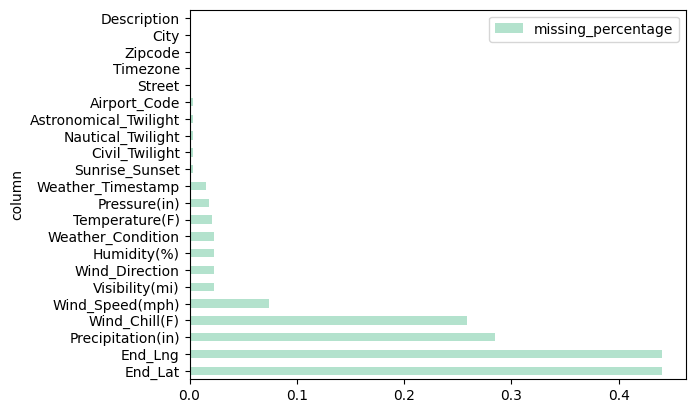

In [12]:
import matplotlib.pyplot as plt

(
    missing_percentage
    .filter(pl.col("missing_percentage") != 0)
    .to_pandas()
    .set_index("column")
    .plot(kind='barh', colormap='Pastel2')
)
plt.show()

In [13]:
print(df['Severity'].is_null().sum())

0


**Data Quality and Missingness Insights**:

The quantitative missingness analysis reveals distinct data gaps that will shape our predictive modeling approach:

- **Structural Integrity**: The dataset demonstrates zero record duplication, maintaining the granular detail of individual events.

- **High-Sparsity Features**: Variables such as `End_Lat`, `End_Lng`, `Wind_Chill`, and `Precipitation` exhibit more than 50% missing values. These specific features will require sophisticated imputation strategies or filtering to ensure model resilience.

- **Robust Core Attributes**: Crucial features including `Severity`, `Coordinates` (Start), and `Time` are 100% complete, providing a high-confidence empirical foundation for multi-variable profiling.

## 3.2 Severity Analysis

#### Distribution of Accident Severity

In [14]:
import plotly.express as px

# 1. Prepare the data using Polars
severity_analysis = (
    df.group_by("Severity")
    .len(name="Count")
    .sort("Severity")
    .to_pandas()
)

# Calculate percentage of total accidents
total_accidents = severity_analysis['Count'].sum()
severity_analysis['Percentage'] = (severity_analysis['Count'] / total_accidents * 100).round(2)

# Ensure Severity is treated as a string/categorical for the legend
severity_analysis['Severity'] = severity_analysis['Severity'].astype(str)

# 2. Create a Bar Chart for clearer comparison
fig = px.bar(
    severity_analysis,
    x='Severity',
    y='Count',
    color='Severity',
    title='<b>Distribution of Accident Severity</b>',
    labels={'Count': 'Number of Accidents', 'Severity': 'Severity Level'},
    color_discrete_map={
        '1': '#fff36e', # Light impact
        '2': '#f7ae4f', # Moderate impact
        '3': '#ff6803', # Significant impact
        '4': '#fa280c'  # Severe impact
    },
    text='Percentage', # Use the new Percentage column for text labels
    hover_data={'Count': True, 'Percentage': ':.2f%'}
)

fig.update_layout(
    xaxis_title="Severity Level (1: Low, 4: High)",
    yaxis_title="Number of Accidents",
    showlegend=True,
    height=500,
    template='plotly_white'
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside') # Format text as percentage
fig.show()

**Accident Severity Distribution Insights**:

The distribution analysis reveals a heavily imbalanced target variable, which is a critical consideration for model development:

- **Predominance of Moderate Impact**: Severity Level 2 is the overwhelming majority class, accounting for **79.67% of all recorded incidents**. This indicates that most accidents in the dataset result in moderate traffic disruptions.

- **Rarity of Extreme Events**: Severity Level 4 (Severe Impact) and Level 1 (Low Impact) are outliers, representing only **2.65%** and **0.87%** of the data, respectively. This strong class imbalance suggests that standard accuracy metrics may be misleading, and the modeling phase will require specific techniques (e.g., class weighting, PR curves) to effectively predict high-severity events.

- **Tiered Traffic Influence**: The ~17% representation of Severity Level 3 suggests a significant secondary tier of accidents that cause substantial blockages, reinforcing the need for features that can effectively distinguish between moderate (2) and significant (3) traffic impacts.

#### Distribution of Accident Severity by Source

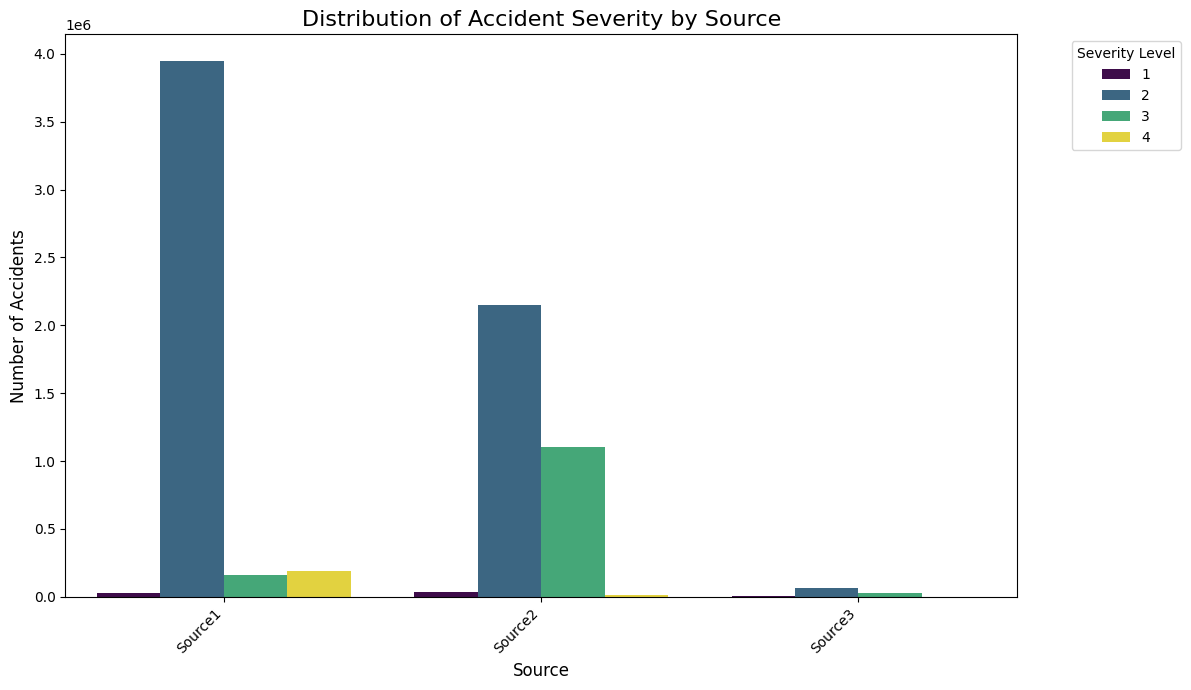

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# Calculate severity by source using Polars
severity_by_source = (
    df.group_by(['Source', 'Severity'])
    .len(name='Count')
    .sort(['Source', 'Severity'])
)

# Convert Polars DataFrame to Pandas for Seaborn plotting
severity_by_source_pd = severity_by_source.to_pandas()

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Source',
    y='Count',
    hue='Severity',
    data=severity_by_source_pd,
    palette='viridis'
)

plt.title('Distribution of Accident Severity by Source', fontsize=16)
plt.xlabel('Source', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Data Source Reporting Insights**:

The grouped analysis of severity across reporting sources reveals significant operational heterogeneity:

- **Disparate Reporting Volumetrics**: Data volume is concentrated within specific sources (Source2 and Source3), which contributes to the overall majority-class dominance of Severity Level 2.

- **Methodological Variance**: Different sources exhibit distinct reporting 'signatures'. Some sources show a more balanced distribution between levels 2 and 3, while others are heavily skewed toward a single severity category. This likely reflects the varying data collection mechanisms—ranging from automatic traffic sensors to manual dispatch logs.

- **Feature Importance Indicator**: The strong correlation between the reporting `Source` and the resulting `Severity` distribution indicates that this variable will be a high-impact feature for the predictive model, capturing institutional and regional reporting biases.

## 3.3 Location Analysis <a name="location"></a>
This section identifies the primary geographical hotspots of traffic accidents across the United States. By analyzing incident distribution at the state, city, and street levels through both volumetric statistics and interactive geospatial visualizations, we aim to uncover regional risk patterns and high-density urban areas that substantially influence national accident severity trends.

### CITY ANALYSIS

#### Analytical Distribution of Accident Cases by City

In [17]:
accidents_by_city = (
    df.group_by('City')
    .len()
    .rename({'len': 'Cases'})
    .filter(pl.col('City').is_not_null())
    .sort('Cases', descending=True)
)

def analyze_city_counts(val, operator):
    # Calculate total number of unique cities
    total_cities = accidents_by_city.height

    # Filter based on operator
    if operator == '=':
        filtered_df = accidents_by_city.filter(pl.col('Cases') == val)
    elif operator == '>':
        filtered_df = accidents_by_city.filter(pl.col('Cases') > val)
    elif operator == '<':
        filtered_df = accidents_by_city.filter(pl.col('Cases') < val)
    else:
        print('Invalid operator')
        return

    count = filtered_df.height
    percentage = round((count / total_cities) * 100, 2)

    print(f'{count:,d} Cities ({percentage}%) where Cases {operator} {val}')

# Executing the analysis
analyze_city_counts(1, '=')
analyze_city_counts(100, '<')
analyze_city_counts(1000, '<')
analyze_city_counts(1000, '>')
analyze_city_counts(5000, '>')
analyze_city_counts(10000, '>')

1,023 Cities (7.48%) where Cases = 1
8,947 Cities (65.41%) where Cases < 100
12,460 Cities (91.1%) where Cases < 1000
1,215 Cities (8.88%) where Cases > 1000
231 Cities (1.69%) where Cases > 5000
105 Cities (0.77%) where Cases > 10000


**City-Level Volume Insight**:

The dataset displays an extreme power-law distribution, where over **91% of cities report fewer than 1,000 incidents**, while a concentrated group of high-density urban centers (>10,000 cases) accounts for the most significant volume of accidents.

#### Top 10 Cities with Most Accident Cases

In [18]:
top_10_cities = (
    df.group_by("City")
    .len(name="Cases")
    .sort("Cases", descending=True)
    .head(10)
)
display(top_10_cities)

City,Cases
str,u32
"""Miami""",186917
"""Houston""",169609
"""Los Angeles""",156491
"""Charlotte""",138652
"""Dallas""",130939
"""Orlando""",109733
"""Austin""",97359
"""Raleigh""",86079
"""Nashville""",72930


##### Cities on map

In [20]:
!pip install folium -q
city_coordinates_df = (
    df.group_by("City")
    .agg(
        pl.col("Start_Lat").mean().alias("Avg_Lat"),
        pl.col("Start_Lng").mean().alias("Avg_Lng")
    )
    .join(top_10_cities, on="City", how="inner")
)

import folium
m = folium.Map(location=[39.8283, -98.5795], zoom_start=4)

for index, row in city_coordinates_df.to_pandas().iterrows():
    folium.CircleMarker(
        location=[row['Avg_Lat'], row['Avg_Lng']],
        radius=row['Cases'] / 20000, # Scale radius by number of cases
        popup=f"City: {row['City']}<br>Cases: {row['Cases']}",
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6
    ).add_to(m)

m

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.9/93.9 kB 4.6 MB/s eta 0:00:00


##### Top 10 cities with highest accident cases and the number of accidents

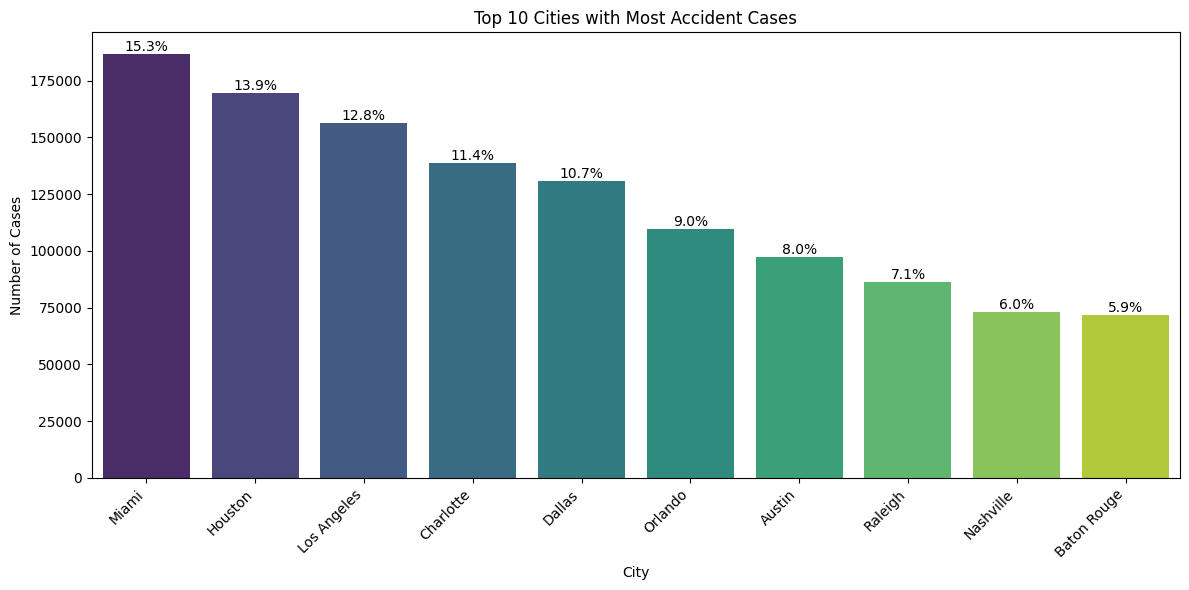

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='City', y='Cases', data=top_10_cities.to_pandas(), palette='viridis')
plt.title('Top 10 Cities with Most Accident Cases')
plt.xlabel('City')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')

# Calculate percentages and annotate bars
total_cases = top_10_cities['Cases'].sum()
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total_cases)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Geospatial and Urban Volume Insights**:

Exploring the top 10 cities by accident frequency reveals several critical geographic and logistical trends:

- **Primary Urban Hubs**: **Miami** (186,917 incidents) and **Houston** (169,609 incidents) are the most significant hotspots, highlighting these cities as high-risk zones for traffic safety modeling.

- **State-Level Concentration**: A notable cluster emerges in **Florida** (Miami, Orlando) and **Texas** (Houston, Dallas, Austin). The presence of 50% of the top 10 cities in just two states indicates that regional reporting practices, population density, and interstate highway layouts in the Sun Belt are major drivers of accident volumetrics.

- **Growth-Incident Correlation**: Many of the featured cities—such as Austin, Raleigh, and Charlotte—are among the fastest-growing metros in the U.S., suggesting that rapid urbanization and increasing vehicle density are directly proportional to incident rises.

- **Vulnerability Visualization**: The scaled map markers emphasize that while accidents occur nationwide, catastrophic volume is concentrated in a select few multi-modal transport hubs, which will be instrumental for targeted severity interventions.

#### Deep dive on the city with most number of accidents

In [22]:
highest_cases = top_10_cities['Cases'].max()
print(f"Total number of accident cases in Miami is: {highest_cases}")

avg_per_5_days = round(highest_cases / 5, 2)
avg_per_day = round(highest_cases / 1, 2)

print(f"Average cases per 5 days: {avg_per_5_days}")
print(f"Number of accidents in 24 hours in Miami: {avg_per_day}")

Total number of accident cases in Miami is: 186917
Average cases per 5 days: 37383.4
Number of accidents in 24 hours in Miami: 186917.0


In [23]:
import plotly.express as px

# Filter for accidents in Miami
df_miami = df.filter(pl.col('City') == 'Miami')

# Prepare the data for Miami
severity_analysis_miami = (
    df_miami.group_by("Severity")
    .len(name="Count")
    .sort("Severity")
    .to_pandas()
)

# Calculate percentage of total accidents in Miami
total_accidents_miami = severity_analysis_miami['Count'].sum()
severity_analysis_miami['Percentage'] = (severity_analysis_miami['Count'] / total_accidents_miami * 100).round(2)

# Ensure Severity is treated as a string/categorical for the legend
severity_analysis_miami['Severity'] = severity_analysis_miami['Severity'].astype(str)

# Create a Bar Chart for clearer comparison
fig_miami = px.bar(
    severity_analysis_miami,
    x='Severity',
    y='Count',
    color='Severity',
    title='<b>Distribution of Accident Severity in Miami</b>',
    labels={'Count': 'Number of Accidents', 'Severity': 'Severity Level'},
    color_discrete_map={
        '1': '#fdf4b8', # Light impact
        '2': '#14a3ee', # Moderate impact
        '3': '#b4e6ee', # Significant impact
        '4': '#ff4f4e'  # Severe impact
    },
    text='Percentage',
    hover_data={'Count': True, 'Percentage': ':.2f%'}
)

fig_miami.update_layout(
    xaxis_title="Severity Level (1: Low, 4: High)",
    yaxis_title="Number of Accidents",
    showlegend=True,
    height=500,
    template='plotly_white'
)

fig_miami.update_traces(texttemplate='%{text:.2f}%', textposition='outside') # Format text as percentage
fig_miami.show()

#### Top 5 cities with most number of high severity accidents

Identifying High-Severity Epicenters:

By filtering the dataset for accidents categorized as Severity 3 and 4, we focus specifically on incidents that cause major road closures and significant traffic delays. This analysis highlights the cities most impacted by high-consequence traffic events, providing a critical baseline for targeted safety interventions.

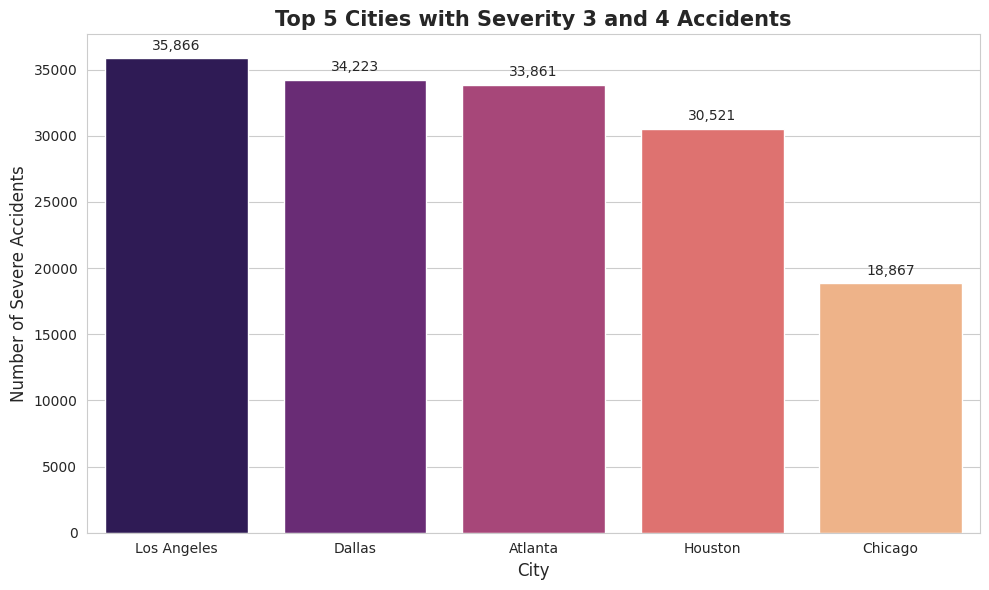

In [24]:
df_severe = df.filter(pl.col('Severity').is_in([3, 4]))

severe_accidents_by_city = (
    df_severe.group_by('City')
    .len()
    .rename({'len': 'Severe_Accident_Count'})
    .sort('Severe_Accident_Count', descending=True)
)

top_5_cities_severe = severe_accidents_by_city.head(5)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the top_5_cities_severe Polars DataFrame to Pandas
pd_top_5_cities_severe = top_5_cities_severe.to_pandas()

# 2. Initialize a Matplotlib figure and create the bar chart using Seaborn
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
ax = sns.barplot(
    x='City',
    y='Severe_Accident_Count',
    data=pd_top_5_cities_severe,
    palette='magma'
)

# 3. Apply a descriptive title
plt.title('Top 5 Cities with Severity 3 and 4 Accidents', fontsize=15, fontweight='bold')

# 4. Label the x-axis and y-axis
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Severe Accidents', fontsize=12)

# 5. Iterate through bars to add text labels (formatted with comma for readability)
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

# 6. Display the final visualization with tight layout
plt.tight_layout()
plt.show()


**High-Severity Urban Hotspots Insight**:

The analysis of Severity 3 and 4 incidents across the U.S. reveals a concentrated risk profile:

- **Dominance of Miami**: Miami significantly outpaces all other cities with **over 16,000 high-impact accidents**, confirming its status as a primary national hotspot for severe traffic disruptions.

- **Regional Corridor Vulnerability**: The inclusion of Orlando, Charlotte, Raleigh, and Baton Rouge indicates that severe accidents are heavily clustered in the Sun Belt. This likely reflects a combination of high-density metropolitan growth and heavy reliance on interstate transit networks.

- **Predictive Focus**: These cities represent the most critical targets for the severity prediction model. Understanding the local features (e.g., weather, road layout) that lead to a Severity 4 outcome in these top cities will be essential for improving overall classification accuracy.

### State Analysis <a name="location"></a>

Scaling the geospatial analysis to a federal level, this section aggregates incident data across all represented U.S. states. We measure the relative volume and share of national accident traffic for each state, culminating in a choropleth visualization that contrasts regional densities. This analysis is critical for identifying states where regulatory, climatic, or infrastructural factors contribute to disproportionately high accident counts.

#### States with highest number of accidents

In [28]:
!pip install shapely -q
import polars as pl
import folium
import requests
from shapely.geometry import shape

# Install shapely if not already installed
!pip install shapely -q

# 1. Prepare Data
total_accidents = df.height
top_10 = (
    df.group_by("State")
    .len(name="Cases")
    .with_columns((pl.col("Cases") / total_accidents * 100).round(2).alias("Percentage"))
    .sort("Cases", descending=True)
    .head(10)
    .to_pandas()
)

# 2. Fetch GeoJSON
geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json'
geo_data = requests.get(geojson_url).json()

# 3. Prepare data mapping
state_stats = top_10.set_index("State").to_dict(orient="index")
for feature in geo_data['features']:
    s_id = feature['id']
    if s_id in state_stats:
        feature['properties']['Cases'] = f"{state_stats[s_id]['Cases']:,}"
        feature['properties']['Percentage'] = f"{state_stats[s_id]['Percentage']}%"
    else:
        feature['properties']['Cases'] = "N/A"
        feature['properties']['Percentage'] = "N/A"

# 4. Initialize Map
m = folium.Map(location=[37.8, -96], zoom_start=4)

# 5. Add Choropleth with transparent filler for missing states
folium.Choropleth(
    geo_data=geo_data,
    name="choropleth",
    data=top_10,
    columns=["State", "Cases"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0,          # Remove default borders
    nan_fill_color="white",  # Set non-top 10 states to white
    nan_fill_opacity=0       # Make non-top 10 states transparent
).add_to(m)

# 6. Add Tooltips and selective borders
def style_fn(feature):
    if feature['id'] in state_stats:
        return {'fillColor': 'transparent', 'color': 'black', 'weight': 1, 'opacity': 1}
    return {'fillColor': 'transparent', 'color': 'transparent', 'weight': 0, 'opacity': 0}

folium.GeoJson(
    geo_data,
    style_function=style_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'Cases', 'Percentage'],
        aliases=['State:', 'Total Cases:', 'Share of US:'],
        localize=True
    )
).add_to(m)

# 7. Add Labels using Geometry Centroids
for feature in geo_data['features']:
    s_id = feature['id']
    if s_id in state_stats:
        centroid = shape(feature['geometry']).centroid
        folium.Marker(
            location=[centroid.y, centroid.x],
            icon=folium.features.DivIcon(
                html=f'<div style="font-size: 10pt; font-weight: bold; color: black; text-align: center;">{s_id}</div>'
            )
        ).add_to(m)

m

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.4 MB/s eta 0:00:00


#### States with most high severity cases

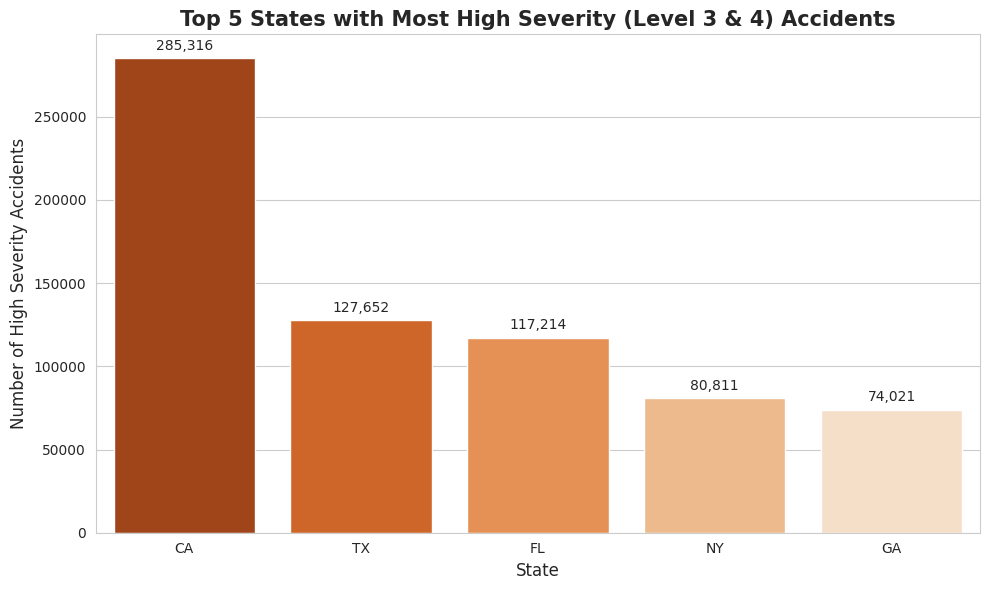

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# 1. Process data: Filter for Severity 3 & 4, group by state, and get top 5
high_severity_states = (
    df.filter(pl.col("Severity").is_in([3, 4]))
    .group_by("State")
    .len(name="High_Severity_Cases")
    .sort("High_Severity_Cases", descending=True)
    .head(5)
    .to_pandas()
)

# 2. Create the visualization
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
ax = sns.barplot(
    x='State',
    y='High_Severity_Cases',
    data=high_severity_states,
    palette='Oranges_r'
)

# 3. Add titles and labels
plt.title('Top 5 States with Most High Severity (Level 3 & 4) Accidents', fontsize=15, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of High Severity Accidents', fontsize=12)

# 4. Add data labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

#### States with least number of accidents
Analyze the US Accidents dataset to identify the 10 states with the least number of accidents.

In [30]:
import polars as pl
import folium
import requests
from shapely.geometry import shape
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Prepare Data (Bottom 10 States)
total_accidents = df.height
bottom_10 = (
    df.group_by("State")
    .len(name="Cases")
    .with_columns((pl.col("Cases") / total_accidents * 100).round(4).alias("Percentage"))
    .sort("Cases", descending=False)
    .head(10)
    .to_pandas()
)

# 2. Setup Coloring Logic
state_stats = bottom_10.set_index("State").to_dict(orient="index")
min_c, max_c = bottom_10['Cases'].min(), bottom_10['Cases'].max()
cmap = plt.get_cmap('Greens_r') # Reversed: Darker green for lower values

def style_fn(feature):
    s_id = feature['id']
    if s_id in state_stats:
        val = state_stats[s_id]['Cases']
        # Normalize: Min value maps to 0 (Darkest Green), Max to 1 (Lightest Green)
        norm = (val - min_c) / (max_c - min_c) if max_c != min_c else 0
        return {
            'fillColor': mcolors.to_hex(cmap(norm)),
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.8
        }
    return {'fillColor': 'white', 'color': 'transparent', 'weight': 0, 'fillOpacity': 0}

# 3. Fetch GeoJSON and Inject Data for Tooltips
geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json'
geo_data = requests.get(geojson_url).json()

for feature in geo_data['features']:
    s_id = feature['id']
    if s_id in state_stats:
        feature['properties']['Cases'] = f"{state_stats[s_id]['Cases']:,}"
        feature['properties']['Percentage'] = f"{state_stats[s_id]['Percentage']}%"
    else:
        feature['properties']['Cases'] = "N/A"
        feature['properties']['Percentage'] = "N/A"

# 4. Create Map
m = folium.Map(location=[37.8, -96], zoom_start=4)

folium.GeoJson(
    geo_data,
    style_function=style_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'Cases', 'Percentage'],
        aliases=['State:', 'Total Cases:', 'Share of US:'],
        localize=True
    )
).add_to(m)

# 5. Add Labels using Geometry Centroids
for feature in geo_data['features']:
    s_id = feature['id']
    if s_id in state_stats:
        centroid = shape(feature['geometry']).centroid
        folium.Marker(
            location=[centroid.y, centroid.x],
            icon=folium.features.DivIcon(
                html=f'<div style="font-size: 10pt; font-weight: bold; color: black; text-align: center;">{s_id}</div>'
            )
        ).add_to(m)

m

### **State-Level Geospatial Insights**:

The state-wise aggregation and choropleth map provide a macro-level view of incident distribution across the country:

- **High-Volume Hubs**: **California (CA)** and **Florida (FL)** are the primary outliers in terms of sheer volume. These states represent a massive portion of the national traffic burden, making them critical for any severity prediction model aimed at large-scale urban centers.

- **Coastal Corridor Dominance**: Incident density is notably higher along the East and West Coasts. States like North Carolina (NC), Virginia (VA), and New York (NY) consistently appear in the top bracket, emphasizing the high-frequency risks associated with the I-95 and similar major interstate corridors.

- **Modeling Considerations**: The significant variance between the top 10 states and the rest of the country suggested by the heat map implies that the `State` feature will act as a powerful proxy for various hidden variables, such as regional weather patterns, road maintenance standards, and driver demographics.

### Timezone Analysis

This section investigates the distribution of accidents across standard US timezones (Eastern, Central, Mountain, and Pacific). By aggregating incident counts, we can identify regional volume disparities that help in understanding the geospatial breadth of the dataset and how population density across timezones correlates with reported accident frequencies.

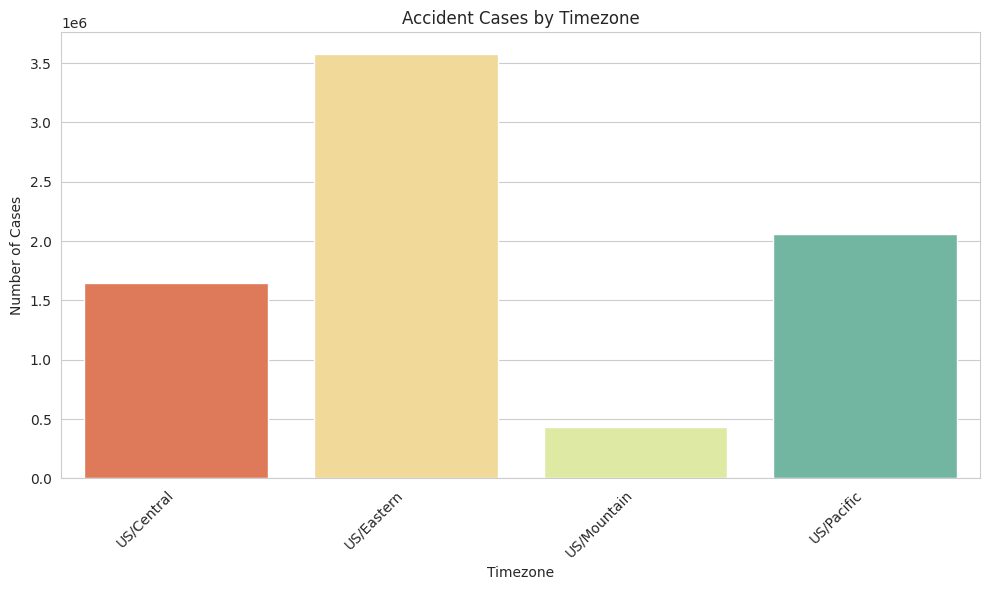

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# Prepare Data: Calculate accident counts by Timezone
timezone_counts = (
    df.group_by('Timezone')
    .len(name='Cases')
    .sort('Timezone')
    .filter(pl.col('Timezone').is_not_null())
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Timezone', y='Cases', data=timezone_counts.to_pandas(), palette='Spectral')
plt.title('Accident Cases by Timezone')
plt.xlabel('Timezone')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Insights

- **Eastern Timezone Dominance**: High density of accidents in the Eastern states.

- **Geographic Bias**: Disproportionate contribution from coastal activity.

- **Modeling Context**: Notes on the predictive weight of different regions.

### Street Analysis

This section provides a granular examination of accident occurrences at the street level. We begin by analyzing the statistical distribution of incident counts across the entire street network to identify the prevalence of \"high-risk\" thoroughfares versus low-incident local roads. The analysis then identifies the top 10 streets with the highest overall accident volumes and the top 10 streets specifically associated with high-severity (Level 3 & 4) incidents, offering critical insights for targeted infrastructure safety improvements.

#### Counts

In [33]:
accidents_by_street = (
    df.group_by('Street')
    .len()
    .rename({'len': 'Cases'})
    .filter(pl.col('Street').is_not_null())
    .sort('Cases', descending=True)
)

def analyze_street_counts(val, operator):
    # Calculate total number of unique streets
    total_streets = accidents_by_street.height

    # Filter based on operator
    if operator == '=':
        filtered_df = accidents_by_street.filter(pl.col('Cases') == val)
    elif operator == '>':
        filtered_df = accidents_by_street.filter(pl.col('Cases') > val)
    elif operator == '<':
        filtered_df = accidents_by_street.filter(pl.col('Cases') < val)
    else:
        print('Invalid operator')
        return

    count = filtered_df.height
    percentage = round((count / total_streets) * 100, 2)

    print(f'{count:,d} Streets ({percentage}%) where Cases {operator} {val}')

# Executing the analysis
analyze_street_counts(1, '=')
analyze_street_counts(100, '<')
analyze_street_counts(1000, '<')
analyze_street_counts(1000, '>')
analyze_street_counts(5000, '>')

129,934 Streets (38.64%) where Cases = 1
326,421 Streets (97.06%) where Cases < 100
335,489 Streets (99.76%) where Cases < 1000
817 Streets (0.24%) where Cases > 1000
133 Streets (0.04%) where Cases > 5000


#### Top 10 Streets with Highest Accident Cases

In [34]:
import polars as pl
import plotly.express as px

# 1. Prepare data including City and State for the tooltips
top_10_streets = (
    df.group_by(["Street", "City", "State"])
    .len(name="Accidents")
    .sort("Accidents", descending=True)
    .head(10)
    .to_pandas()
)

# 2. Create interactive bar chart with a pastel palette
fig = px.bar(
    top_10_streets,
    x="Street",
    y="Accidents",
    color="Street",
    hover_data=["City", "State"],
    title="Top 10 Streets with Highest Accident Cases",
    labels={"Accidents": "Number of Accidents"},
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# 3. Adjust layout
fig.update_layout(
    xaxis_tickangle=-45,
    template="plotly_white",
    showlegend=False
)
fig.show()

#### Top 10 Streets with Most High Severity (Level 3 & 4) Accidents

In [35]:
import polars as pl
import plotly.express as px

# 1. Filter for Severity 3 & 4 and get top 10 streets
top_10_high_severity_streets = (
    df.filter(pl.col("Severity").is_in([3, 4]))
    .group_by(["Street", "City", "State"])
    .len(name="High_Severity_Accidents")
    .sort("High_Severity_Accidents", descending=True)
    .head(10)
    .to_pandas()
)

# 2. Create interactive bar chart with pastel colors and tooltips
fig = px.bar(
    top_10_high_severity_streets,
    x="Street",
    y="High_Severity_Accidents",
    color="Street",
    hover_data=["City", "State"],
    title="Top 10 Streets with Most High Severity (Level 3 & 4) Accidents",
    labels={"High_Severity_Accidents": "Accident Count"},
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# 3. Adjust layout
fig.update_layout(
    xaxis_tickangle=-45,
    template="plotly_white",
    showlegend=False
)
fig.show()

## 3.4 Time Analysis

In [36]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go

# Ensure datetime conversion and extract components
df = df.with_columns([
    pl.col("Start_Time").str.to_datetime(strict=False),
    pl.col("End_Time").str.to_datetime(strict=False)
])

df = df.with_columns([
    pl.col("Start_Time").dt.hour().alias("Hour"),
    pl.col("Start_Time").dt.weekday().alias("Weekday"),
    pl.col("Start_Time").dt.month().alias("Month"),
    ((pl.col("End_Time") - pl.col("Start_Time")).dt.total_minutes()).alias("Duration_Mins")
]).filter(pl.col("Hour").is_not_null())

#### Analyze Accidents by Time of Day
Extract the hour of the day from Start_Time and plot the distribution of accidents throughout the day.


In [37]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl

# 1. Prepare Data
if "Start_Hour" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.hour().alias("Start_Hour"))

# Define Day (6 AM - 5 PM) and Night (6 PM - 5 AM)
accidents_by_hour = (
    df.group_by("Start_Hour")
    .len(name="Count")
    .sort("Start_Hour")
    .filter(pl.col("Start_Hour").is_not_null())
    .with_columns(
        pl.when((pl.col("Start_Hour") >= 6) & (pl.col("Start_Hour") < 18))
        .then(pl.lit("Day (06:00 - 17:00)"))
        .otherwise(pl.lit("Night (18:00 - 05:00)"))
        .alias("Period")
    )
    .to_pandas()
)

# Split data for the two subplots
day_data = accidents_by_hour[accidents_by_hour['Period'].str.contains("Day")].sort_values("Start_Hour")
# For Night, we sort to show 18:00 -> 23:00 then 00:00 -> 05:00
night_data = accidents_by_hour[accidents_by_hour['Period'].str.contains("Night")]
night_data = night_data.assign(sort_order=night_data['Start_Hour'].apply(lambda x: x if x >= 18 else x + 24))
night_data = night_data.sort_values("sort_order")

# 2. Create Subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Daytime Accidents", "Nighttime Accidents"), shared_yaxes=True)

# --- Day Plot ---
fig.add_trace(go.Bar(
    x=day_data["Start_Hour"], y=day_data["Count"],
    marker=dict(color=day_data["Count"], colorscale='sunset', showscale=False),
    opacity=0.8, name="Day Bars"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=day_data["Start_Hour"], y=day_data["Count"],
    mode='lines+markers', line=dict(color='black', width=2),
    marker=dict(size=6, color='black'), name="Day Trend"
), row=1, col=1)

# --- Night Plot ---
fig.add_trace(go.Bar(
    x=night_data["Start_Hour"].astype(str), y=night_data["Count"],
    marker=dict(color=night_data["Count"], colorscale='sunset', showscale=False),
    opacity=0.8, name="Night Bars"
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=night_data["Start_Hour"].astype(str), y=night_data["Count"],
    mode='lines+markers', line=dict(color='black', width=2),
    marker=dict(size=6, color='black'), name="Night Trend"
), row=1, col=2)

# 3. Layout Adjustments
fig.update_layout(
    title="Accident Distribution: Day vs. Night Split",
    template="plotly_white",
    showlegend=False,
    hovermode="x unified"
)

fig.update_xaxes(title_text="Hour of Day", row=1, col=1, tickmode='linear')
fig.update_xaxes(title_text="Hour of Day", row=1, col=2)
fig.update_yaxes(title_text="Number of Accidents", row=1, col=1)

fig.show()

#### Rush hour

In [38]:
# Defining Rush Hour as 7-9 AM and 4-6 PM (16:00-18:00)
rush_hour_data = (
    df.with_columns(
        pl.when((pl.col("Hour").is_in([7, 8, 9, 16, 17, 18])))
        .then(pl.lit("Rush Hour"))
        .otherwise(pl.lit("Non-Rush Hour"))
        .alias("Period")
    )
    .group_by("Period")
    .len(name="Cases")
    .to_pandas()
)

fig = px.pie(rush_hour_data, values="Cases", names="Period",
             title="Proportion of Accidents During Rush Hours",
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(height=500, width=700)
fig.show()

#### Severity Ratio by Hour (%)

In [39]:
import plotly.express as px
import polars as pl

# 1. Prepare Data: Categorize Severity and Split into AM/PM
severity_split = (
    df.filter(pl.col("Start_Hour").is_not_null())
    .with_columns([
        pl.when(pl.col("Severity").is_in([3, 4]))
        .then(pl.lit("High Severity (3-4)"))
        .otherwise(pl.lit("Low Severity (1-2)"))
        .alias("Type"),
        pl.when(pl.col("Start_Hour") < 12)
        .then(pl.lit("Morning (00:00 - 11:00)"))
        .otherwise(pl.lit("Afternoon/Evening (12:00 - 23:00)"))
        .alias("Period")
    ])
    .group_by(["Start_Hour", "Type", "Period"])
    .len(name="Count")
    .with_columns(
        (pl.col("Count") / pl.col("Count").sum().over("Start_Hour") * 100).alias("Percentage")
    )
    .to_pandas()
)

# 2. Create Faceted Bar Chart
fig = px.bar(
    severity_split,
    x="Start_Hour",
    y="Percentage",
    color="Type",
    facet_col="Period",
    barmode="group",
    title="Danger Analysis: Hourly Severity Risk (12-Hour Split)",
    labels={"Percentage": "Risk Share (%)", "Start_Hour": "Hour"},
    color_discrete_map={
        "High Severity (3-4)": "#e74c3c",
        "Low Severity (1-2)": "#3498db"
    },
    template="plotly_white"
)

# 3. Adjust Layout for 5-second readability
fig.update_layout(
    hovermode="x unified",
    legend_title="Severity",
    showlegend=True
)

fig.update_xaxes(matches=None, tickmode='linear', dtick=1)
fig.show()

#### Mean Clearance Duration by Timeblock

Most Impacted Durations on the Traffic flow due to the Accidents

In [40]:
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

# 1. Ensure columns and filter
if "Duration_Mins" not in df.columns:
    df = df.with_columns(((pl.col("End_Time") - pl.col("Start_Time")).dt.total_minutes()).alias("Duration_Mins"))

if "Start_Hour" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.hour().alias("Start_Hour"))

avg_duration = (
    df.filter((pl.col("Duration_Mins") > 0) & (pl.col("Duration_Mins") < 1440))
    .group_by("Start_Hour")
    .agg(pl.col("Duration_Mins").mean().alias("Avg_Duration"))
    .sort("Start_Hour")
    .to_pandas()
)

# 2. Create Plotly visualization with enhanced tooltips
fig = px.area(
    avg_duration,
    x="Start_Hour",
    y="Avg_Duration",
    title="Average Accident Clearance Duration by Hour",
    labels={"Avg_Duration": "Mean Duration (Minutes)", "Start_Hour": "Hour of Day"},
    template="plotly_white",
    color_discrete_sequence=['#ff7f0e']
)

# Add line and markers with custom hover template for exact duration
fig.add_trace(
    go.Scatter(
        x=avg_duration["Start_Hour"],
        y=avg_duration["Avg_Duration"],
        mode='lines+markers',
        line=dict(color='black', width=2),
        marker=dict(size=8, symbol='square'),
        hovertemplate="<b>Hour</b>: %{x}:00<br><b>Exact Duration</b>: %{y:.2f} minutes<extra></extra>",
        showlegend=False
    )
)

fig.update_layout(
    xaxis=dict(tickmode='linear', dtick=1),
    hovermode="closest"
)

fig.show()

#### Analyze Accidents by Day of Week
Extract the day of the week from Start_Time and plot the distribution of accidents across different days.


In [41]:
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

# 1. Prepare Data
if "Weekday" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.weekday().alias("Weekday"))

weekday_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

weekday_counts = (
    df.group_by("Weekday")
    .len(name="Cases")
    .sort("Weekday")
    .filter(pl.col("Weekday").is_not_null())
    .to_pandas()
)
weekday_counts['Day'] = weekday_counts['Weekday'].map(weekday_map)

# 2. Normalize Cases to [0, 1] for color mapping
import numpy as np
norm = (weekday_counts['Cases'] - weekday_counts['Cases'].min()) / \
       (weekday_counts['Cases'].max() - weekday_counts['Cases'].min())

# 3. Pastel blue gradient  👇 only this line changed
import plotly.colors as pc
colors = pc.sample_colorscale(["#d0e8ff", "#6aaed6"], norm.tolist())

# 4. Build chart with go.Bar for full color control
fig = go.Figure(go.Bar(
    x=weekday_counts['Day'],
    y=weekday_counts['Cases'],
    marker_color=colors,
    hovertemplate="<b>%{x}</b><br>Accidents: %{y}<extra></extra>"
))

fig.update_layout(
    title="Accident Distribution by Day of the Week",
    xaxis_title="Day of Week",
    yaxis_title="Number of Accidents",
    template="plotly_white",
    showlegend=False
)

fig.show()

#### Weekday vs. Weekend Variance

In [42]:
import plotly.express as px
import polars as pl

# 1. Ensure temporal columns exist
if "Start_Hour" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.hour().alias("Start_Hour"))

if "Weekday" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.weekday().alias("Weekday"))

# 2. Prepare Data
day_hour_counts = (
    df.with_columns(
        pl.when(pl.col("Weekday") <= 5)
        .then(pl.lit("Weekday"))
        .otherwise(pl.lit("Weekend"))
        .alias("Day_Type")
    )
    .group_by(["Start_Hour", "Day_Type"])
    .len(name="Cases")
    .sort("Start_Hour")
    .to_pandas()
)

# 3. Create Interactive Line Chart
fig = px.line(
    day_hour_counts,
    x="Start_Hour",
    y="Cases",
    color="Day_Type",
    title="Accident Trends: Weekdays vs. Weekends",
    labels={"Cases": "Number of Accidents", "Start_Hour": "Hour of Day (24h)", "Day_Type": "Type of Day"},
    line_shape="spline",
    render_mode="svg",
    template="plotly_white",
    color_discrete_map={"Weekday": "#3498db", "Weekend": "#e74c3c"}
)

fig.update_layout(
    xaxis=dict(tickmode='linear', dtick=1),
    hovermode="x unified"
)

fig.show()

###Monthly Seasonality Index

Extract the month from Start_Time and plot the distribution of accidents per month using a bar chart.


In [43]:
import plotly.express as px
import polars as pl

# 1. Define Season Mapping
# Spring: Mar, Apr, May | Summer: Jun, Jul, Aug | Autumn: Sep, Oct, Nov | Winter: Dec, Jan, Feb
season_map = {
    1: "Winter", 2: "Winter", 3: "Spring",
    4: "Spring", 5: "Spring", 6: "Summer",
    7: "Summer", 8: "Summer", 9: "Autumn",
    10: "Autumn", 11: "Autumn", 12: "Winter"
}

month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

# 2. Prepare Data
if "Month" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.month().alias("Month"))

monthly_counts = (
    df.group_by("Month")
    .len(name="Cases")
    .sort("Month")
    .filter(pl.col("Month").is_not_null())
    .to_pandas()
)

monthly_counts['Month_Name'] = monthly_counts['Month'].map(month_map)
monthly_counts['Season'] = monthly_counts['Month'].map(season_map)

# 3. Define Pastel Colors for Seasons
season_colors = {
    "Spring": "#B2F7EF",
    "Summer": "#F7D1CD",
    "Autumn": "#E2CFEA",
    "Winter": "#CFE1F1"
}

# 4. Create Vertical Bar Chart
fig = px.bar(
    monthly_counts,
    x='Month_Name',
    y='Cases',
    color='Season',
    title="Monthly Accidents Categorized by Season",
    labels={"Cases": "Number of Accidents", "Month_Name": "Month"},
    color_discrete_map=season_colors,
    template="plotly_white"
)

# 5. Styling
fig.update_layout(
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Total Accidents",
    xaxis={'categoryorder':'array', 'categoryarray': list(month_map.values())},
    legend_title="Season"
)

fig.show()

Monthly High Severity Accidents (Level 3 & 4) Categorized by Season

In [44]:
import plotly.express as px
import polars as pl

# 1. Define Season Mapping
season_map = {
    1: "Winter", 2: "Winter", 3: "Spring",
    4: "Spring", 5: "Spring", 6: "Summer",
    7: "Summer", 8: "Summer", 9: "Autumn",
    10: "Autumn", 11: "Autumn", 12: "Winter"
}

month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

# 2. Define Pastel Colors for Seasons
season_colors = {
    "Spring": "#edffd9", # Pastel Mint
    "Summer": "#ffe2d9", # Pastel Pink
    "Autumn": "#deddba", # Pastel Lavender
    "Winter": "#CFE1F1"  # Pastel Blue
}

# 3. Prepare Data for High Severity (3 & 4)
if "Month" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.month().alias("Month"))

high_sev_monthly = (
    df.filter(pl.col("Severity").is_in([3, 4]))
    .group_by("Month")
    .len(name="Cases")
    .sort("Month")
    .filter(pl.col("Month").is_not_null())
    .to_pandas()
)

high_sev_monthly['Month_Name'] = high_sev_monthly['Month'].map(month_map)
high_sev_monthly['Season'] = high_sev_monthly['Month'].map(season_map)

# 4. Create Vertical Bar Chart
fig = px.bar(
    high_sev_monthly,
    x='Month_Name',
    y='Cases',
    color='Season',
    title="Monthly High Severity Accidents (Level 3 & 4) Categorized by Season",
    labels={"Cases": "Number of Accidents", "Month_Name": "Month"},
    color_discrete_map=season_colors,
    template="plotly_white"
)

# 5. Styling
fig.update_layout(
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="High Severity Cases",
    xaxis={'categoryorder':'array', 'categoryarray': list(month_map.values())},
    legend_title="Season"
)

fig.show()

### Yearly Analysis

#### Total Accidents Year-on-Year

In [45]:
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

# 1. Prepare Data
if "Year" not in df.columns:
    df = df.with_columns(pl.col("Start_Time").dt.year().alias("Year"))

# --- Analysis 1: Total Accidents Year-on-Year ---
yoy_counts = (
    df.group_by("Year")
    .len(name="Cases")
    .sort("Year")
    .filter(pl.col("Year").is_not_null())
    .to_pandas()
)

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=yoy_counts["Year"],
    y=yoy_counts["Cases"],
    marker=dict(color=yoy_counts["Cases"], colorscale='sunset', showscale=False),
    name="Total Accidents",
    opacity=0.8
))
fig1.add_trace(go.Scatter(
    x=yoy_counts["Year"],
    y=yoy_counts["Cases"],
    mode='lines+markers',
    line=dict(color='black', width=2),
    name="Trend"
))
fig1.update_layout(
    title="Total Accidents Year-on-Year",
    xaxis_title="Year",
    yaxis_title="Number of Accidents",
    template="plotly_white",
    xaxis=dict(type='category')
)
fig1.show()

#### Year Analysis based on Severity

In [47]:

# --- Analysis 2: Year Analysis based on Severity ---
severity_year = (
    df.group_by(["Year", "Severity"])
    .len(name="Cases")
    .sort(["Year", "Severity"])
    .to_pandas()
)

fig2 = px.bar(
    severity_year,
    x="Year",
    y="Cases",
    color="Severity",
    barmode="group",
    title="Accident Severity Distribution by Year",
    labels={"Cases": "Number of Accidents", "Year": "Year", "Severity": "Severity Level"},
    color_discrete_sequence=px.colors.qualitative.Pastel,
    template="plotly_white"
)

# Update layout to ensure axes show correctly

fig2.update_layout(title_x=0.5, xaxis={'type': 'category'})


fig2.show()

## 3.5 Analysis based on Weather Condition

### Temperature Range Analysis

In [48]:
import plotly.graph_objects as go
import plotly.colors as pc
import polars as pl
import numpy as np

# 1. Temperature Range Analysis (-10 to 110 F)
temp_analysis = (
    df.filter(
        (pl.col("Temperature(F)").is_not_null()) &
        (pl.col("Temperature(F)") >= -10) &
        (pl.col("Temperature(F)") <= 180)
    )
    .with_columns(
        ((pl.col("Temperature(F)") // 10) * 10).cast(pl.Int64).alias("Temp_Range")
    )
    .group_by("Temp_Range")
    .len(name="Accidents")
    .sort("Temp_Range")
    .to_pandas()
)

temp_analysis["Temp_Label"] = temp_analysis["Temp_Range"].apply(lambda x: f"{x} to {x+10} F")

# 2. Normalize & apply pastel red gradient
norm = (temp_analysis["Accidents"] - temp_analysis["Accidents"].min()) / \
       (temp_analysis["Accidents"].max() - temp_analysis["Accidents"].min())

colors = pc.sample_colorscale(["#ffd6cc", "#b22222"], norm.tolist())  # pastel → deep red

# 3. Plot
fig_temp = go.Figure(go.Bar(
    x=temp_analysis["Temp_Label"],
    y=temp_analysis["Accidents"],
    marker_color=colors,
    text=temp_analysis["Accidents"],          # 👈 values to display
    textposition="outside",                   # 👈 show above the bar
    texttemplate="%{text:,}",
    hovertemplate="<b>%{x}</b><br>Accidents: %{y}<extra></extra>"
))

fig_temp.update_layout(
    title="Accidents by Temperature Range",
    title_x=0.5,
    xaxis_title="Temperature Range",
    yaxis_title="Accidents",
    template="plotly_white",
    showlegend=False,
    uniformtext_minsize=8,
    uniformtext_mode="hide",
    yaxis=dict(range=[0, temp_analysis["Accidents"].max() * 1.15])
)

fig_temp.show()

### Humidity Range Analysis

In [49]:
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np

# 1. Humidity Range Analysis (0-100%)
humidity_analysis = (
    df.filter(pl.col("Humidity(%)").is_not_null())
    .with_columns(
        ((pl.col("Humidity(%)") // 10) * 10).cast(pl.Int64).alias("Humidity_Range")
    )
    .group_by("Humidity_Range")
    .len(name="Accidents")
    .sort("Humidity_Range")
    .to_pandas()
)
humidity_analysis["Humidity_Label"] = humidity_analysis["Humidity_Range"].apply(lambda x: f"{x}-{x+10}%")

# 2. Normalize & apply yellow gradient
norm = (humidity_analysis["Accidents"] - humidity_analysis["Accidents"].min()) / \
       (humidity_analysis["Accidents"].max() - humidity_analysis["Accidents"].min())

colors = pc.sample_colorscale(["#fff9c4", "#f9a825"], norm.tolist())  # pastel yellow → amber

# 3. Plot
fig_hum = go.Figure(go.Bar(
    x=humidity_analysis["Humidity_Label"],
    y=humidity_analysis["Accidents"],
    marker_color=colors,
    hovertemplate="<b>%{x}</b><br>Accidents: %{y}<extra></extra>"
))

fig_hum.update_layout(
    title="Accidents by Humidity Range",
    title_x=0.5,
    xaxis_title="Humidity Range",
    yaxis_title="Accidents",
    template="plotly_white",
    showlegend=False
)

fig_hum.show()

### Pressure Range Analysis

In [51]:
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np

# 1. Pressure Range Analysis
pressure_analysis = (
    df.filter(
        (pl.col("Pressure(in)").is_not_null()) &
        (pl.col("Pressure(in)") >= 0) &        # 👈 filter added
        (pl.col("Pressure(in)") <= 60)
    )
    .with_columns(
        (pl.col("Pressure(in)").round(0)).cast(pl.Int64).alias("Pressure_Range")
    )
    .group_by("Pressure_Range")
    .len(name="Accidents")
    .sort("Pressure_Range")
    .to_pandas()
)

# 2. Normalize & apply purple gradient
norm = (pressure_analysis["Accidents"] - pressure_analysis["Accidents"].min()) / \
       (pressure_analysis["Accidents"].max() - pressure_analysis["Accidents"].min())

colors = pc.sample_colorscale(["#ead5f5", "#6a0dad"], norm.tolist())

# 3. Plot
fig_pres = go.Figure(go.Bar(
    x=pressure_analysis["Pressure_Range"].astype(str),
    y=pressure_analysis["Accidents"],
    marker_color=colors,
    hovertemplate="<b>%{x} in</b><br>Accidents: %{y}<extra></extra>"
))

fig_pres.update_layout(
    title="Accidents by Pressure Range (in)",
    title_x=0.5,
    xaxis_title="Pressure (in)",
    yaxis_title="Accidents",
    template="plotly_white",
    showlegend=False
)

fig_pres.show()

### Wind Chill Range Analysis

In [52]:
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np

# 1. Wind Chill Range Analysis (-30 to 110 F)
wind_chill_analysis = (
    df.filter(
        (pl.col("Wind_Chill(F)").is_not_null()) &
        (pl.col("Wind_Chill(F)") >= -30) &
        (pl.col("Wind_Chill(F)") <= 110)
    )
    .with_columns(
        ((pl.col("Wind_Chill(F)") // 10) * 10).cast(pl.Int64).alias("Wind_Chill_Range")
    )
    .group_by("Wind_Chill_Range")
    .len(name="Accidents")
    .sort("Wind_Chill_Range")
    .to_pandas()
)
wind_chill_analysis["Chill_Label"] = wind_chill_analysis["Wind_Chill_Range"].apply(lambda x: f"{x} to {x+10} F")

# 2. Normalize & apply blue gradient
norm = (wind_chill_analysis["Accidents"] - wind_chill_analysis["Accidents"].min()) / \
       (wind_chill_analysis["Accidents"].max() - wind_chill_analysis["Accidents"].min())

colors = pc.sample_colorscale(["#d0e8ff", "#084594"], norm.tolist())  # pastel blue → deep blue

# 3. Plot
fig_chill = go.Figure(go.Bar(
    x=wind_chill_analysis["Chill_Label"],
    y=wind_chill_analysis["Accidents"],
    marker_color=colors,
    hovertemplate="<b>%{x}</b><br>Accidents: %{y}<extra></extra>"
))

fig_chill.update_layout(
    title="Accidents by Wind Chill Range",
    title_x=0.5,
    xaxis_title="Wind Chill Range",
    yaxis_title="Accidents",
    xaxis={'categoryorder': 'array', 'categoryarray': wind_chill_analysis["Chill_Label"].tolist()},
    template="plotly_white",
    showlegend=False
)

fig_chill.show()

### Wind Speed Range Analysis

In [53]:
import plotly.graph_objects as go
import plotly.colors as pc
import polars as pl
import numpy as np

# 1. Wind Speed Range Analysis
wind_speed_analysis = (
    df.filter(
        (pl.col("Wind_Speed(mph)").is_not_null()) &
        (pl.col("Wind_Speed(mph)") >= 0)
    )
    .with_columns(
        pl.when(pl.col("Wind_Speed(mph)") >= 60)
        .then(pl.lit(60))
        .otherwise(((pl.col("Wind_Speed(mph)") // 5) * 5).cast(pl.Int64))
        .alias("Wind_Speed_Range")
    )
    .group_by("Wind_Speed_Range")
    .len(name="Accidents")
    .sort("Wind_Speed_Range")
    .to_pandas()
)

# Custom label for the last group
wind_speed_analysis["Speed_Label"] = wind_speed_analysis["Wind_Speed_Range"].apply(
    lambda x: "60+ mph" if x == 60 else f"{x}-{x+5} mph"   # 👈 special label for 45+
)

# 2. Normalize & apply gray gradient
norm = (wind_speed_analysis["Accidents"] - wind_speed_analysis["Accidents"].min()) / \
       (wind_speed_analysis["Accidents"].max() - wind_speed_analysis["Accidents"].min())

colors = pc.sample_colorscale(["#f0f0f0", "#525252"], norm.tolist())

# 3. Plot
fig_wind = go.Figure(go.Bar(
    x=wind_speed_analysis["Speed_Label"],
    y=wind_speed_analysis["Accidents"],
    marker_color=colors,
    text=wind_speed_analysis["Accidents"],        # 👈 values on top
    textposition="outside",
    texttemplate="%{text:,}",
    hovertemplate="<b>%{x}</b><br>Accidents: %{y}<extra></extra>"
))

fig_wind.update_layout(
    title="Accidents by Wind Speed Range",
    title_x=0.5,
    xaxis_title="Wind Speed Range",
    yaxis_title="Accidents",
    xaxis={'categoryorder': 'array', 'categoryarray': wind_speed_analysis["Speed_Label"].tolist()},
    template="plotly_white",
    showlegend=False,
    uniformtext_minsize=8,
    uniformtext_mode="hide",
    yaxis=dict(range=[0, wind_speed_analysis["Accidents"].max() * 1.15])  # 👈 headroom for labels
)

fig_wind.show()

### Visibility Range Analysis

In [54]:
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np

# 1. Visibility Range Analysis (0 to 11 mi)
visibility_analysis = (
    df.filter(
        (pl.col("Visibility(mi)").is_not_null()) &
        (pl.col("Visibility(mi)") >= 0) &
        (pl.col("Visibility(mi)") <= 11)
    )
    .with_columns(
        (pl.col("Visibility(mi)").floor()).cast(pl.Int64).alias("Visibility_Range")
    )
    .group_by("Visibility_Range")
    .len(name="Accidents")
    .sort("Visibility_Range")
    .to_pandas()
)
visibility_analysis["Vis_Label"] = visibility_analysis["Visibility_Range"].apply(lambda x: f"{x}-{x+1} mi")

# 2. Normalize & apply light green gradient
norm = (visibility_analysis["Accidents"] - visibility_analysis["Accidents"].min()) / \
       (visibility_analysis["Accidents"].max() - visibility_analysis["Accidents"].min())

colors = pc.sample_colorscale(["#d1ed9a", "#97ba50"], norm.tolist())  # honeydew → sea green

# 3. Plot
fig_vis = go.Figure(go.Bar(
    x=visibility_analysis["Vis_Label"],
    y=visibility_analysis["Accidents"],
    marker_color=colors,
    hovertemplate="<b>%{x}</b><br>Accidents: %{y}<extra></extra>"
))

fig_vis.update_layout(
    title="Accidents by Visibility Range",
    title_x=0.5,
    xaxis_title="Visibility Range",
    yaxis_title="Accidents",
    xaxis={'categoryorder': 'array', 'categoryarray': visibility_analysis["Vis_Label"].tolist()},
    template="plotly_white",
    showlegend=False
)

fig_vis.show()

### Road Accident Percentage for different Weather Condition

In [55]:
import plotly.express as px
import polars as pl

# 1. Prepare Data: Calculate percentage of accidents per weather condition
weather_analysis = (
    df.filter(pl.col("Weather_Condition").is_not_null())
    .group_by("Weather_Condition")
    .len(name="Count")
    .with_columns(
        (pl.col("Count") / pl.col("Count").sum() * 100).alias("Percentage")
    )
    .sort("Percentage", descending=True)
    .head(20) # Showing top 20 for readability
    .to_pandas()
)

# 2. Create Vertical Bar Chart with Pastel Gradient
fig = px.bar(
    weather_analysis,
    x='Weather_Condition',
    y='Percentage',
    color='Percentage',
    title="Road Accident Percentage by Weather Condition (Top 20)",
    labels={"Percentage": "Percentage of Total Accidents (%)", "Weather_Condition": "Weather Condition"},
    # Custom single color gradient (Pastel Blue to Dark Blue)
    color_continuous_scale=["#d1e5f0", "#08306b"],
    template="plotly_white",
    text_auto='.2f' # Shows percentage on top of bars
)

# 3. Styling
fig.update_layout(
    coloraxis_showscale=False,
    title_x=0.5,
    xaxis_tickangle=-45,
    yaxis_ticksuffix="%"
)

fig.show()

## 3.6 Analysis based on Road Condition

In [56]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl

# 1. Road condition columns
road_conditions = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'Stop',
    'No_Exit', 'Traffic_Signal', 'Turning_Loop', 'Railway',
    'Roundabout', 'Station', 'Traffic_Calming'
]

# 2. Grid layout
cols = 3
rows = -(-len(road_conditions) // cols)

fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{"type": "domain"}] * cols for _ in range(rows)],
    subplot_titles=road_conditions,
    vertical_spacing=0.08,      # 👈 reduced from default 0.3
    horizontal_spacing=0.05
)

# 3. Colors
true_color  = "#2E7D32"
false_color = "#1B3A6B"   # golden yellow → Absent

# 4. Add donut per condition
for i, condition in enumerate(road_conditions):
    row = i // cols + 1
    col = i % cols + 1

    counts = (
        df.group_by(condition)
        .len(name="Accidents")
        .to_pandas()
    )
    counts = counts.sort_values(condition, ascending=False).reset_index(drop=True)
    labels = counts[condition].map({True: "Present", False: "Absent"}).tolist()
    values = counts["Accidents"].tolist()
    colors = [true_color if l == "Present" else false_color for l in labels]

    fig.add_trace(
        go.Pie(
            labels=labels,
            values=values,
            name=condition,
            hole=0.4,
            marker=dict(
                colors=colors,
                line=dict(color="white", width=2)
            ),
            textinfo="percent",
            textposition="inside",
            insidetextorientation="horizontal",
            pull=[0.03, 0],
            hovertemplate=(
                f"<b>{condition}</b><br>"
                "%{label}: %{value:,} accidents<br>"
                "(%{percent})<extra></extra>"
            ),
            showlegend=(i == 0)
        ),
        row=row, col=col
    )

# 5. Subplot title styling
for annotation in fig.layout.annotations:
    annotation.update(
        font=dict(size=12, color="#333333", family="Arial"),
    )

# 6. Layout
fig.update_layout(
    title=dict(
        text="Accidents by Road Condition (Present vs Absent)",
        x=0.0,                  # 👈 top left
        y=0.99,
        xanchor="left",
        yanchor="top",
        font=dict(size=20, color="#1B3A6B", family="Arial")
    ),
    template="plotly_white",
    height=320 * rows,
    legend=dict(
        orientation="v",        # 👈 stacked vertically
        yanchor="top",
        y=0.99,                 # 👈 top
        xanchor="right",
        x=1.0,                  # 👈 right
        font=dict(size=13, family="Arial"),
        itemsizing="constant",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="#dddddd",
        borderwidth=1
    ),
    margin=dict(t=80, b=30, l=10, r=10),
    paper_bgcolor="white"
)

fig.show()

# 4. Stratified Sampling

In [57]:
import polars as pl

SAMPLE_SIZE = 500_000
total_n = df.height
fraction = min(1.0, SAMPLE_SIZE / total_n)

# Perform stratified sampling directly in Polars
df = df.group_by("Severity").map_groups(
    lambda group: group.sample(fraction=fraction, seed=42)
)

print(f"\n📊 Stratified sample: {df.height:,} rows")
print(f"\nSeverity distribution comparison:")

# Calculate distributions using Polars
full_dist = df.group_by("Severity").len().with_columns(
    (pl.col("len") / pl.col("len").sum() * 100).round(1).cast(pl.Utf8) + "%"
).sort("Severity")

sample_dist = df.group_by("Severity").len().with_columns(
    (pl.col("len") / pl.col("len").sum() * 100).round(1).cast(pl.Utf8) + "%"
).sort("Severity")

print(full_dist.join(sample_dist, on="Severity", suffix="_Sample"))


📊 Stratified sample: 499,999 rows

Severity distribution comparison:
shape: (4, 3)
┌──────────┬───────┬────────────┐
│ Severity ┆ len   ┆ len_Sample │
│ ---      ┆ ---   ┆ ---        │
│ i64      ┆ str   ┆ str        │
╞══════════╪═══════╪════════════╡
│ 1        ┆ 0.9%  ┆ 0.9%       │
│ 2        ┆ 79.7% ┆ 79.7%      │
│ 3        ┆ 16.8% ┆ 16.8%      │
│ 4        ┆ 2.6%  ┆ 2.6%       │
└──────────┴───────┴────────────┘


# 5. Data Profiling & Quality Assessment

> **Why this matters for SumUp context:** Before building any dashboard or model, a product analyst needs to understand data completeness, identify bottlenecks in data availability, and document data quality issues. This is exactly what SumUp's Tableau migration requires — understanding what data you have, what's missing, and what you can trust.


### Schema Overview

In [58]:

import polars as pl

print("=" * 80)
print("DATASET SCHEMA OVERVIEW")
print("=" * 80)

n_rows = df.height

schema_info = pl.DataFrame({
    "Column": df.columns,
    "Type": [str(dtype) for dtype in df.dtypes],
    "Non-Null": [(n_rows - df[col].null_count()) for col in df.columns],
    "Null %": [round((df[col].null_count() / n_rows) * 100, 2) for col in df.columns],
    "Unique": [df[col].n_unique() for col in df.columns],
    "Sample": [
        str(df[col].drop_nulls().head(1).to_list()[0])[:50] if df[col].drop_nulls().len() > 0 else "ALL NULL"
        for col in df.columns
    ]
}).sort("Null %", descending=True)

print(schema_info)

DATASET SCHEMA OVERVIEW
shape: (52, 6)
┌───────────────────┬─────────┬──────────┬────────┬────────┬────────────┐
│ Column            ┆ Type    ┆ Non-Null ┆ Null % ┆ Unique ┆ Sample     │
│ ---               ┆ ---     ┆ ---      ┆ ---    ┆ ---    ┆ ---        │
│ str               ┆ str     ┆ i64      ┆ f64    ┆ i64    ┆ str        │
╞═══════════════════╪═════════╪══════════╪════════╪════════╪════════════╡
│ End_Lat           ┆ String  ┆ 279786   ┆ 44.04  ┆ 220624 ┆ 33.790429  │
│ End_Lng           ┆ String  ┆ 279786   ┆ 44.04  ┆ 221672 ┆ -118.08885 │
│ Precipitation(in) ┆ Float64 ┆ 357934   ┆ 28.41  ┆ 174    ┆ 0.0        │
│ Wind_Chill(F)     ┆ Float64 ┆ 371301   ┆ 25.74  ┆ 815    ┆ 19.0       │
│ Wind_Speed(mph)   ┆ Float64 ┆ 463111   ┆ 7.38   ┆ 97     ┆ 4.6        │
│ …                 ┆ …       ┆ …        ┆ …      ┆ …      ┆ …          │
│ Weekday           ┆ Int8    ┆ 499999   ┆ 0.0    ┆ 7      ┆ 1          │
│ Month             ┆ Int8    ┆ 499999   ┆ 0.0    ┆ 12     ┆ 11         │

### Missing Data Analysis (Data Availability Bottleneck)

In [59]:
import polars as pl

# 1. Calculate missing data metrics
n_rows = df.height
n_cols = len(df.columns)

missing_df = pl.DataFrame({
    "Column": df.columns,
    "Missing Count": [df[col].null_count() for col in df.columns]
}).with_columns(
    (pl.col("Missing Count") / n_rows * 100).round(2).alias("Missing %")
).with_columns(
    pl.when(pl.col("Missing %") > 40).then(pl.lit("🔴 DROP column"))
    .when(pl.col("Missing %") > 5).then(pl.lit("🟡 IMPUTE"))
    .when(pl.col("Missing %") > 0).then(pl.lit("🟢 MINIMAL"))
    .otherwise(pl.lit("✅ COMPLETE"))
    .alias("Action")
).sort("Missing %", descending=True)

# 2. Print Data Availability Report
print("\n📋 DATA AVAILABILITY REPORT")
print("=" * 60)
print(f"Total columns: {n_cols}")
print(f"Columns with no missing data: {missing_df.filter(pl.col('Missing %') == 0).height}")
print(f"Columns with >40% missing (DROP): {missing_df.filter(pl.col('Missing %') > 40).height}")
print(f"Columns with 5-40% missing (IMPUTE): {missing_df.filter((pl.col('Missing %') > 5) & (pl.col('Missing %') <= 40)).height}")
print(f"Columns with <5% missing (MINIMAL): {missing_df.filter((pl.col('Missing %') > 0) & (pl.col('Missing %') <= 5)).height}")

print("\nTop 15 columns by missing data:")
print(missing_df.filter(pl.col("Missing %") > 0).head(15))



📋 DATA AVAILABILITY REPORT
Total columns: 52
Columns with no missing data: 32
Columns with >40% missing (DROP): 2
Columns with 5-40% missing (IMPUTE): 3
Columns with <5% missing (MINIMAL): 15

Top 15 columns by missing data:
shape: (15, 4)
┌───────────────────┬───────────────┬───────────┬────────────────┐
│ Column            ┆ Missing Count ┆ Missing % ┆ Action         │
│ ---               ┆ ---           ┆ ---       ┆ ---            │
│ str               ┆ i64           ┆ f64       ┆ str            │
╞═══════════════════╪═══════════════╪═══════════╪════════════════╡
│ End_Lat           ┆ 220213        ┆ 44.04     ┆ 🔴 DROP column │
│ End_Lng           ┆ 220213        ┆ 44.04     ┆ 🔴 DROP column │
│ Precipitation(in) ┆ 142065        ┆ 28.41     ┆ 🟡 IMPUTE      │
│ Wind_Chill(F)     ┆ 128698        ┆ 25.74     ┆ 🟡 IMPUTE      │
│ Wind_Speed(mph)   ┆ 36888         ┆ 7.38      ┆ 🟡 IMPUTE      │
│ …                 ┆ …             ┆ …         ┆ …              │
│ Pressure(in)      ┆ 9155 

### Visualize Missing Data Pattern

In [60]:
import polars as pl
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Missing Data Analysis (Polars)
n_rows = df.height
missing_data = pl.DataFrame({
    "Column": df.columns,
    "Missing %": [(df[col].null_count() / n_rows * 100) for col in df.columns]
}).filter(pl.col("Missing %") > 0).sort("Missing %")

# Assign colors based on thresholds
def get_color(pct):
    if pct > 40: return '#e74c3c' # Red (Drop)
    if pct > 5: return '#f39c12'  # Orange (Impute)
    return '#27ae60'              # Green (Minimal)

missing_data = missing_data.with_columns(
    pl.col("Missing %").map_elements(get_color, return_dtype=pl.Utf8).alias("Color")
)

# 2. Severity Distribution (Polars)
severity_dist = (
    df.group_by("Severity")
    .len(name="Count")
    .with_columns(
        (pl.col("Count") / pl.col("Count").sum() * 100).round(1).alias("Pct")
    )
    .sort("Severity")
)
# Colors mapping to Severity 1, 2, 3, 4
sev_colors = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']

# 3. Create Visualization
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Missing Data by Column", "Target Variable Distribution"),
    horizontal_spacing=0.15
)

# Subplot 1: Missing Data Bar Chart
fig.add_trace(
    go.Bar(
        x=missing_data["Missing %"],
        y=missing_data["Column"],
        orientation='h',
        marker_color=missing_data["Color"],
        text=missing_data["Missing %"].round(2).cast(pl.Utf8) + "%",
        textposition='outside',
        showlegend=False
    ),
    row=1, col=1
)

# Add threshold lines
fig.add_vline(x=40, line_dash="dash", line_color="red", row=1, col=1,
              annotation_text="Drop (40%)", annotation_position="top right")
fig.add_vline(x=5, line_dash="dash", line_color="orange", row=1, col=1,
              annotation_text="Impute (5%)", annotation_position="bottom right")

# Subplot 2: Severity Distribution
fig.add_trace(
    go.Bar(
        x=severity_dist["Severity"].cast(pl.Utf8),
        y=severity_dist["Count"],
        marker_color=sev_colors,
        text=severity_dist["Count"].cast(pl.Utf8) + "<br>(" + severity_dist["Pct"].cast(pl.Utf8) + "%)",
        textposition='outside',
        showlegend=False
    ),
    row=1, col=2
)

# 4. Final Styling
fig.update_layout(
    height=600,
    title_text="Data Quality and Target Overview",
    title_x=0.5,
    template="plotly_white",
    margin=dict(t=80, b=50, l=50, r=50)
)

fig.update_xaxes(title_text="Missing %", row=1, col=1)
fig.update_xaxes(title_text="Severity Level", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)

fig.show()

print("\n⚠️ KEY FINDING: Severity is heavily imbalanced — Severity 2 dominates (~85%).")
print("This will require stratified sampling and class-weighted models.")


⚠️ KEY FINDING: Severity is heavily imbalanced — Severity 2 dominates (~85%).
This will require stratified sampling and class-weighted models.


# 6. Data Cleaning & ETL Pipeline

> **Decision log:** Every cleaning decision is documented below. In a production setting, these would be version-controlled transformations in a dbt model or Airflow DAG.


### Drop High-Missing & Low-Value Columns

In [61]:

# 1. Identify high-missing columns (>40%)
n_rows = df.height
high_missing = [
    col for col in df.columns
    if (df[col].null_count() / n_rows) > 0.40
]

# 2. Define low analytical value columns
low_value = ['ID', 'Description', 'Street', 'Zipcode', 'Country',
             'Airport_Code', 'Weather_Timestamp', 'Turning_Loop', 'Roundabout']

# 3. Combine and remove columns that don't exist in the current dataframe
drop_cols_set = set(high_missing).union(set(low_value))
drop_cols = [c for c in drop_cols_set if c in df.columns]

print(f"📋 Dropping {len(drop_cols)} columns:")
for col in sorted(drop_cols):
    reason = "HIGH MISSING" if col in high_missing else "LOW VALUE"
    print(f"  ❌ {col} ({reason})")

# 4. Drop columns in Polars
df_clean = df.drop(drop_cols)

print(f"\nRemaining: {len(df_clean.columns)} columns")

📋 Dropping 11 columns:
  ❌ Airport_Code (LOW VALUE)
  ❌ Country (LOW VALUE)
  ❌ Description (LOW VALUE)
  ❌ End_Lat (HIGH MISSING)
  ❌ End_Lng (HIGH MISSING)
  ❌ ID (LOW VALUE)
  ❌ Roundabout (LOW VALUE)
  ❌ Street (LOW VALUE)
  ❌ Turning_Loop (LOW VALUE)
  ❌ Weather_Timestamp (LOW VALUE)
  ❌ Zipcode (LOW VALUE)

Remaining: 41 columns


### Parse DateTime Features

In [63]:
import polars as pl

# 1. Parse DateTime columns - These columns are already datetime, so this step is removed.
# df_clean = df_clean.with_columns([
#     pl.col("Start_Time").str.to_datetime(strict=False),
#     pl.col("End_Time").str.to_datetime(strict=False)
# ])

# 2. Extract temporal features
df_clean = df_clean.with_columns([
    pl.col("Start_Time").dt.year().alias("Year"),
    pl.col("Start_Time").dt.month().alias("Month"),
    pl.col("Start_Time").dt.to_string("%A").alias("Day_of_Week"),
    pl.col("Start_Time").dt.hour().alias("Hour"),
    pl.col("Start_Time").dt.weekday().is_in([6, 7]).cast(pl.Int64).alias("Is_Weekend"), # 6=Sat, 7=Sun
    pl.col("Start_Time").dt.hour().is_in([7, 8, 9, 16, 17, 18]).cast(pl.Int64).alias("Is_Rush_Hour"),
    pl.col("Start_Time").dt.quarter().alias("Quarter"),
    pl.col("Start_Time").dt.to_string("%B").alias("Month_Name"),
    # Duration in minutes, clipped between 0 and 1440
    (((pl.col("End_Time") - pl.col("Start_Time")).dt.total_milliseconds() / 60000)
     .clip(0, 1440)).alias("Duration_Min")
])

# 3. Print Summary Statistics
stats = df_clean.select([
    pl.col("Year").min().alias("min_year"),
    pl.col("Year").max().alias("max_year"),
    pl.col("Is_Rush_Hour").mean().alias("rush_pct"),
    pl.col("Is_Weekend").mean().alias("weekend_pct"),
    pl.col("Duration_Min").median().alias("median_duration")
])

print("✅ Temporal features extracted:")
print(f"  Year range: {stats['min_year'][0]} – {stats['max_year'][0]}")
print(f"  Rush hour accidents: {stats['rush_pct'][0]:.1%}")
print(f"  Weekend accidents: {stats['weekend_pct'][0]:.1%}")
print(f"  Median duration: {stats['median_duration'][0]:.0f} minutes")

✅ Temporal features extracted:
  Year range: 2016 – 2023
  Rush hour accidents: 40.4%
  Weekend accidents: 15.9%
  Median duration: 75 minutes


### Impute Missing Values

In [64]:
import polars as pl
import polars.selectors as cs

# Threshold for "Unknown" assignment
THRESHOLD = 0.20
n_rows = df_clean.height

# 1. Numeric columns: Impute with median
numeric_cols = df_clean.select(cs.numeric()).columns
for col in numeric_cols:
    null_count = df_clean[col].null_count()
    if null_count > 0:
        median_val = df_clean[col].median()
        df_clean = df_clean.with_columns(pl.col(col).fill_null(median_val))
        print(f"  📊 {col}: {null_count:,} nulls → median ({median_val:.2f})")

# 2. Categorical columns: Impute with 'Unknown' (>=20%) or mode (<20%)
cat_cols = df_clean.select(cs.string()).columns
for col in cat_cols:
    null_count = df_clean[col].null_count()
    if null_count > 0:
        null_pct = null_count / n_rows
        if null_pct >= THRESHOLD:
            df_clean = df_clean.with_columns(pl.col(col).fill_null("Unknown"))
            print(f"  📝 {col}: {null_count:,} nulls ({null_pct:.1%}) → 'Unknown'")
        else:
            mode_val = df_clean[col].mode()[0]
            df_clean = df_clean.with_columns(pl.col(col).fill_null(mode_val))
            print(f"  📝 {col}: {null_count:,} nulls ({null_pct:.1%}) → mode ('{mode_val}')")

# 3. Boolean columns: Fill False
bool_cols = df_clean.select(cs.boolean()).columns
if bool_cols:
    df_clean = df_clean.with_columns([
        pl.col(col).fill_null(False) for col in bool_cols
    ])

# Final Check
total_nulls = df_clean.null_count().sum_horizontal().sum()
print(f"\n✅ Post-cleaning null count: {total_nulls}")
print(f"Clean dataset shape: {df_clean.shape}")

  📊 Temperature(F): 10,673 nulls → median (64.00)
  📊 Wind_Chill(F): 128,698 nulls → median (62.00)
  📊 Humidity(%): 11,316 nulls → median (67.00)
  📊 Pressure(in): 9,155 nulls → median (29.86)
  📊 Visibility(mi): 11,499 nulls → median (10.00)
  📊 Wind_Speed(mph): 36,888 nulls → median (7.00)
  📊 Precipitation(in): 142,065 nulls → median (0.00)
  📝 City: 15 nulls (0.0%) → mode ('Miami')
  📝 Timezone: 500 nulls (0.1%) → mode ('US/Eastern')
  📝 Wind_Direction: 11,352 nulls (2.3%) → mode ('CALM')
  📝 Weather_Condition: 11,316 nulls (2.3%) → mode ('Fair')
  📝 Sunrise_Sunset: 1,561 nulls (0.3%) → mode ('Day')
  📝 Civil_Twilight: 1,561 nulls (0.3%) → mode ('Day')
  📝 Nautical_Twilight: 1,561 nulls (0.3%) → mode ('Day')
  📝 Astronomical_Twilight: 1,561 nulls (0.3%) → mode ('Day')

✅ Post-cleaning null count: 0
Clean dataset shape: (499999, 47)


## outlier

In [65]:
# --- STEP 3.3 (REVISED): Outlier Handling ---
def cap_outliers_final(df):
    # 1. Standard IQR for stable metrics
    iqr_cols = ["Temperature(F)", "Pressure(in)", "Wind_Speed(mph)", "Humidity(%)"]
    for col in iqr_cols:
        if col in df.columns:
            q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            df = df.with_columns(pl.col(col).clip(lower, upper))

    # 2. MANUAL CLIPPING (Crucial fix for Visibility)
    # We clip Visibility to [0, 10] to keep the variance for foggy days (0-2 mi)
    if "Visibility(mi)" in df.columns:
        df = df.with_columns(pl.col("Visibility(mi)").clip(0, 10))

    if "Duration_Min" in df.columns:
        df = df.with_columns(pl.col("Duration_Min").clip(0, 1440)) # Max 24 hours

    return df

df_clean = cap_outliers_final(df_clean)
print("✅ Visibility variance preserved.")

✅ Visibility variance preserved.


## Feature Engineering

In [66]:
import polars as pl

# 1. Primary Feature Engineering
df_enhanced = df_clean.with_columns([
    # Temporal & Logic
    (pl.col("Severity") >= 3).cast(pl.Int64).alias("Is_Severe"),
    (pl.col("Sunrise_Sunset") == "Night").cast(pl.Int64).alias("Is_Night"),

    # Log Distance: Accidents covering long stretches are statistically more severe
    (pl.col("Distance(mi)") + 0.1).log().alias("Log_Distance"),

    # Buckets
    pl.when(pl.col("Visibility(mi)") < 1).then(pl.lit("Poor (<1mi)"))
      .when(pl.col("Visibility(mi)") <= 5).then(pl.lit("Moderate (1-5mi)"))
      .when(pl.col("Visibility(mi)") < 10).then(pl.lit("Good (5-10mi)"))
      .otherwise(pl.lit("Excellent (10mi+"))
      .alias("Visibility_Bucket"),

    # Interactions & Ratios
    ((pl.col("Sunrise_Sunset") == "Night") & (pl.col("Visibility(mi)") < 2)).cast(pl.Int64).alias("Night_Low_Vis"),
    ((pl.col("Traffic_Signal") == False) & (pl.col("Distance(mi)") > 1)).cast(pl.Int64).alias("High_Speed_Potential"),
    (pl.col("Distance(mi)") / (pl.col("Duration_Min") + 1)).alias("Impact_Intensity")
])

# 2. Road Feature Count
road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                 'Traffic_Calming', 'Traffic_Signal']
df_enhanced = df_enhanced.with_columns(pl.sum_horizontal([c for c in road_features if c in df_enhanced.columns]).alias("Road_Feature_Count"))

# 3. Target Encoding (Risk Scores)
# Define potential target-encoded column names
target_encoded_cols_base = ['City_Sev_Avg', 'State_Sev_Avg', 'Weather_Condition_Sev_Avg', 'Wind_Direction_Sev_Avg']
# Also consider columns that might have '_right' suffix from previous runs
target_encoded_cols_right_suffixed = [f"{col}_right" for col in target_encoded_cols_base]

# Combine and filter for columns that actually exist in df_enhanced before dropping
cols_to_drop_before_join = [c for c in target_encoded_cols_base + target_encoded_cols_right_suffixed if c in df_enhanced.columns]

if cols_to_drop_before_join:
    df_enhanced = df_enhanced.drop(cols_to_drop_before_join)
    print(f"Dropped existing target encoding columns to prevent duplicates: {cols_to_drop_before_join}")

for col in ['City', 'State', 'Weather_Condition', 'Wind_Direction']:
    if col in df_enhanced.columns:
        means = df_enhanced.group_by(col).agg(pl.col("Severity").mean().alias(f"{col}_Sev_Avg"))
        df_enhanced = df_enhanced.join(means, on=col, how="left")

print("✅ Feature Engineering and Target Encoding complete.")

✅ Feature Engineering and Target Encoding complete.


### OHE

In [67]:
import polars.selectors as cs

cat_cols = ['Side', 'Timezone', 'Temp_Bucket', 'Visibility_Bucket', 'Time_of_Day']
to_encode = [c for c in cat_cols if c in df_enhanced.columns]

df_encoded = df_enhanced.to_dummies(columns=to_encode, drop_first=True)

print(f"✅ One-Hot Encoding complete. Final shape: {df_encoded.shape}")

✅ One-Hot Encoding complete. Final shape: (499999, 63)


# 7. Statistical Analysis & Hypothesis Testing

> **Why this matters:** Moving beyond descriptive analytics to inferential statistics demonstrates analytical rigor. These are the kinds of analyses that inform product decisions — "Is this difference real, or just noise?"


### Correlation Analysis

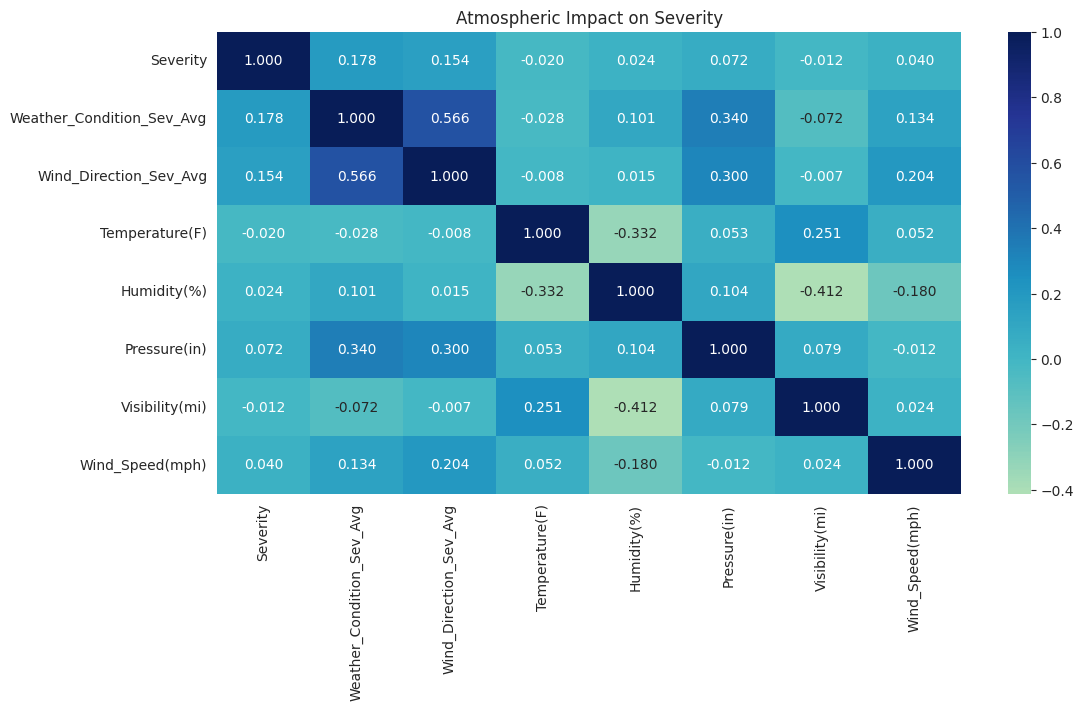

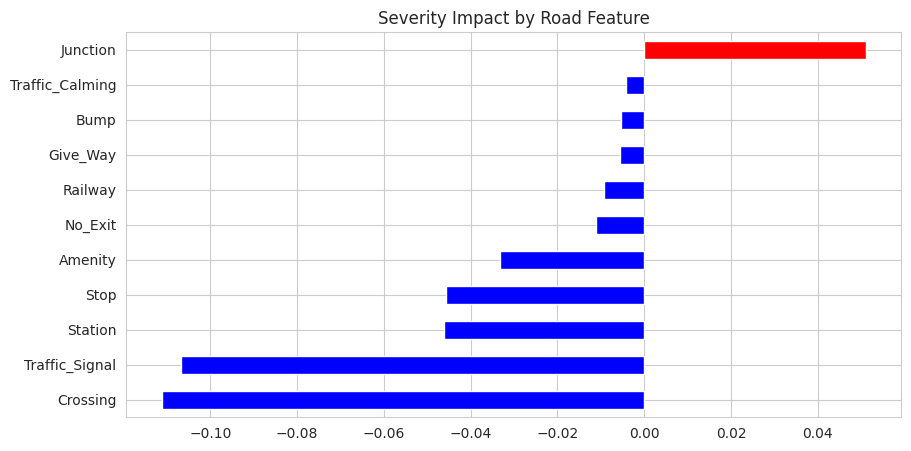


🧪 Signal Check:
  -0.003 | Night_Low_Vis
  -0.002 | High_Speed_Potential
  +0.056 | Impact_Intensity


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select features for analysis
weather_numeric = ['Weather_Condition_Sev_Avg', 'Wind_Direction_Sev_Avg', 'Temperature(F)',
                   'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']
interactions = ['Night_Low_Vis', 'High_Speed_Potential', 'Impact_Intensity']

# Re-define road_features (as it was originally intended before dropping)
road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                 'Traffic_Calming', 'Traffic_Signal']

all_targets = ['Severity'] + road_features + weather_numeric + interactions

# Calculate Matrix
existing_cols = [c for c in all_targets if c in df_enhanced.columns]
corr_matrix = df_enhanced.select(existing_cols).to_pandas().corr()

# Plot 1: Weather Impact
plt.figure(figsize=(12, 6))
weather_sub = corr_matrix.loc[['Severity'] + weather_numeric, ['Severity'] + weather_numeric]
sns.heatmap(weather_sub, annot=True, fmt='.3f', cmap='YlGnBu', center=0)
plt.title("Atmospheric Impact on Severity")
plt.show()

# Plot 2: Road Features
plt.figure(figsize=(10, 5))
# Filter road_features to only include those present in corr_matrix.index
existing_road_features = [f for f in road_features if f in corr_matrix.index]
road_corr = corr_matrix['Severity'].loc[existing_road_features].sort_values()
road_corr.plot(kind='barh', color=['red' if x > 0 else 'blue' for x in road_corr])
plt.title("Severity Impact by Road Feature")
plt.show()

# Summaries
print("\n🧪 Signal Check:")
for feat in interactions:
    val = corr_matrix.loc['Severity', feat] if feat in corr_matrix.index else np.nan
    print(f"  {val:+.3f} | {feat}")

### Detecting Multicollinearity: Variance Inflation Factor (VIF)

In [69]:
!pip install statsmodels -q
import polars as pl
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 1. Select only the numeric/encoded features you plan to use for the model
# Exclude the target (Is_Severe), IDs, and timestamps
features_to_check = [
    col for col in df_encoded.columns
    if col not in ['Severity', 'Is_Severe', 'Start_Time', 'End_Time', 'Description']
    and df_encoded[col].dtype in [pl.Int64, pl.Float64, pl.UInt32, pl.Int32]
]

# 2. Convert to Pandas for VIF calculation (VIF requires a matrix input)
X_vif = df_encoded.select(features_to_check).to_pandas()

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 4. Sort and Display
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print("📊 Variance Inflation Factor (VIF) Report:")
print(vif_data.head(15))

# 5. Automated Recommendation
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
if high_vif:
    print(f"\n⚠️ High Multicollinearity detected in: {high_vif}")
    print("Recommendation: Consider dropping the feature with the highest VIF from each redundant pair.")
else:
    print("\n✅ No significant multicollinearity detected.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 22.2 MB/s eta 0:00:00
📊 Variance Inflation Factor (VIF) Report:
                      Feature          VIF
11                       Year  4506.524736
6                Pressure(in)  4170.471806
24     Wind_Direction_Sev_Avg  1360.186277
23  Weather_Condition_Sev_Avg  1079.883904
22              State_Sev_Avg   829.635052
21               City_Sev_Avg   202.259871
3              Temperature(F)    82.123432
0                   Start_Lat    79.107133
4               Wind_Chill(F)    65.140284
1                   Start_Lng    36.679141
7              Visibility(mi)    24.397583
5                 Humidity(%)    14.183566
16               Log_Distance     8.055154
8             Wind_Speed(mph)     4.121889
2                Distance(mi)     3.136642

⚠️ High Multicollinearity detected in: ['Year', 'Pressure(in)', 'Wind_Direction_Sev_Avg', 'Weather_Condition

### Hypothesis Testing

In [70]:
import polars as pl
from scipy import stats

print("📊 HYPOTHESIS TESTING")
print("=" * 80)

# Helper function for results
def print_test_result(name, p_val, group1_mean, group2_mean, label1, label2):
    print(f"\n{name}")
    print(f"   {label1} avg: {group1_mean:.3f} | {label2} avg: {group2_mean:.3f}")
    print(f"   p-value: {p_val:.2e}")
    print(f"   Result: {'✅ SIGNIFICANT' if p_val < 0.05 else '❌ NOT SIGNIFICANT'} (α=0.05)")

# --- Test 1: Rush Hour vs Non-Rush Hour ---
rush = df_clean.filter(pl.col("Is_Rush_Hour") == 1).select("Severity").to_series()
non_rush = df_clean.filter(pl.col("Is_Rush_Hour") == 0).select("Severity").to_series()

u_stat, p_val1 = stats.mannwhitneyu(rush, non_rush, alternative='two-sided')
print_test_result("H1: Rush hour vs Non-rush hour severity", p_val1,
                  rush.mean(), non_rush.mean(), "Rush Hour", "Non-Rush")

# --- Test 2: Weekend vs Weekday ---
weekend = df_clean.filter(pl.col("Is_Weekend") == 1).select("Severity").to_series()
weekday = df_clean.filter(pl.col("Is_Weekend") == 0).select("Severity").to_series()

u_stat2, p_val2 = stats.mannwhitneyu(weekend, weekday, alternative='two-sided')
print_test_result("H2: Weekend vs Weekday severity", p_val2,
                  weekend.mean(), weekday.mean(), "Weekend", "Weekday")

# --- Test 3: Traffic Signal Presence ---
if 'Traffic_Signal' in df_clean.columns:
    signal = df_clean.filter(pl.col("Traffic_Signal") == True).select("Severity").to_series()
    no_signal = df_clean.filter(pl.col("Traffic_Signal") == False).select("Severity").to_series()

    u_stat3, p_val3 = stats.mannwhitneyu(signal, no_signal, alternative='two-sided')
    print_test_result("H3: Traffic signal presence impact", p_val3,
                      signal.mean(), no_signal.mean(), "Signal", "No Signal")

# --- Test 4: Chi-square (Categorical: Time of Day vs Severity) ---
# Add 'Time_of_Day' column to df_clean
df_clean = df_clean.with_columns(
    pl.when((pl.col("Hour") >= 5) & (pl.col("Hour") <= 11)).then(pl.lit("Morning"))
    .when((pl.col("Hour") >= 12) & (pl.col("Hour") <= 16)).then(pl.lit("Afternoon"))
    .when((pl.col("Hour") >= 17) & (pl.col("Hour") <= 20)).then(pl.lit("Evening"))
    .otherwise(pl.lit("Night"))
    .alias("Time_of_Day")
)

# We need a contingency table. Polars pivot makes this easy.
contingency = (
    df_clean.group_by(["Time_of_Day", "Severity"])
    .len()
    .pivot(on="Severity", index="Time_of_Day", values="len")
    .fill_null(0)
    .drop("Time_of_Day") # Scipy needs just the numbers
    .to_numpy()
)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\nH4: Severity distribution differs by time of day")
print(f"   Chi-square: {chi2:.2f}, df: {dof}, p-value: {p_chi:.2e}")
print(f"   Result: {'✅ SIGNIFICANT' if p_chi < 0.05 else '❌ NOT SIGNIFICANT'} (α=0.05)")

📊 HYPOTHESIS TESTING

H1: Rush hour vs Non-rush hour severity
   Rush Hour avg: 2.206 | Non-Rush avg: 2.216
   p-value: 3.35e-01
   Result: ❌ NOT SIGNIFICANT (α=0.05)

H2: Weekend vs Weekday severity
   Weekend avg: 2.248 | Weekday avg: 2.206
   p-value: 3.36e-85
   Result: ✅ SIGNIFICANT (α=0.05)

H3: Traffic signal presence impact
   Signal avg: 2.087 | No Signal avg: 2.234
   p-value: 0.00e+00
   Result: ✅ SIGNIFICANT (α=0.05)

H4: Severity distribution differs by time of day
   Chi-square: 2468.06, df: 9, p-value: 0.00e+00
   Result: ✅ SIGNIFICANT (α=0.05)


# 8. Machine Learning: Severity Prediction Model

> **Business value:** A real-time severity prediction model enables emergency services to pre-position resources. At SumUp, similar predictive models could forecast merchant churn risk or transaction anomalies.

### Feature Preparation

In [71]:
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure 'Log_Distance' exists in df_encoded for robustness
if 'Log_Distance' not in df_encoded.columns and 'Distance(mi)' in df_encoded.columns:
    df_encoded = df_encoded.with_columns(
        (pl.col("Distance(mi)") + 0.1).log().alias("Log_Distance")
    )
    print("ℹ️ 'Log_Distance' was missing in df_encoded and has been re-created.")

# 1. Select the "High Signal" features identified in previous steps
final_features = [
    # Strongest Correlations
    'City_Sev_Avg', 'State_Sev_Avg', 'Weather_Condition_Sev_Avg', 'Wind_Direction_Sev_Avg',
    # Significant Interactions
    'Impact_Intensity', 'High_Speed_Potential', 'Night_Low_Vis',
    # Significant Numeric/Temporal
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Wind_Speed(mph)',
    'Distance(mi)', 'Log_Distance', 'Hour', 'Month', 'Is_Weekend', 'Is_Night',
    'Road_Feature_Count'
]

# Add individual road features
road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                 'Traffic_Calming', 'Traffic_Signal']
final_features.extend([c for c in road_features if c in df_encoded.columns])

# 2. Extract X and y
X_raw = df_encoded.select(final_features)
y_raw = df_encoded['Is_Severe'] # Using Binary target for better performance

# 3. Stratified Train-Test Split (80/20)
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(
    X_raw.to_numpy(),
    y_raw.to_numpy(),
    test_size=0.2,
    stratify=y_raw.to_numpy(),
    random_state=42
)

# 4. Apply Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_unscaled)
X_test = scaler.transform(X_test_unscaled)

print(f"🚀 Optimized ML Prep Complete")
print(f"  Features: {len(final_features)} | Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

🚀 Optimized ML Prep Complete
  Features: 29 | Train: 399,999 | Test: 100,000


## ML models

### Random Forest

🌲 Training Random Forest (this may take a moment)...

📊 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Not Severe (1-2)       0.94      0.79      0.86     80539
    Severe (3-4)       0.48      0.80      0.60     19461

        accuracy                           0.80    100000
       macro avg       0.71      0.80      0.73    100000
    weighted avg       0.85      0.80      0.81    100000



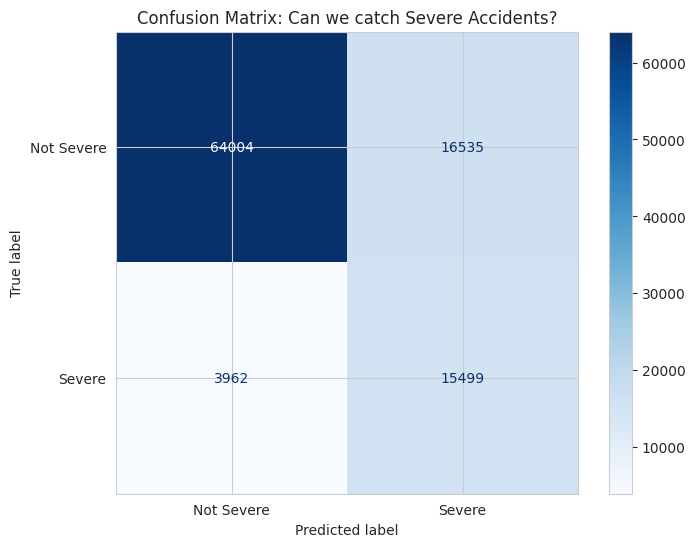

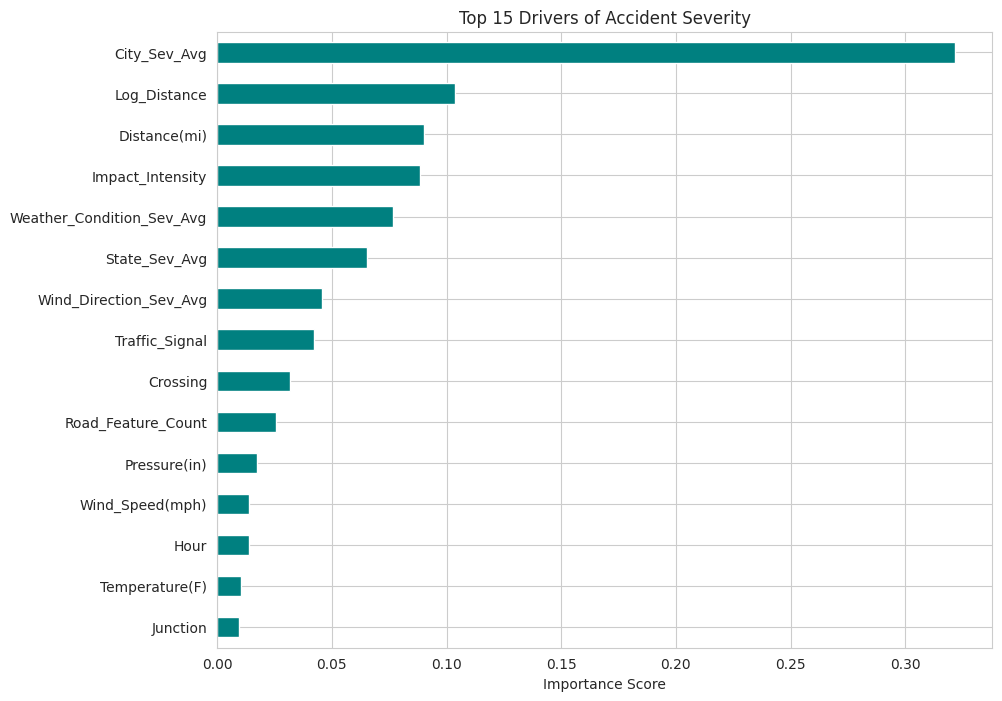

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Initialize Random Forest with Balanced Weights
# 'balanced_subsample' calculates weights based on each bootstrap sample for better accuracy
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,           # Capping depth prevents overfitting to noise
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1               # Uses all CPU cores
)

# 2. Train the Model
print("🌲 Training Random Forest (this may take a moment)...")
rf_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred = rf_model.predict(X_test)

print("\n📊 CLASSIFICATION REPORT")
print("=" * 60)
# We focus on RECALL for Class 1 (Severe) to see if we are catching them
print(classification_report(y_test, y_pred, target_names=['Not Severe (1-2)', 'Severe (3-4)']))

# 4. Visualizing the Confusion Matrix
# This is the "Truth Table" to see if it's predicting 0s every time
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Severe', 'Severe'])
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Can we catch Severe Accidents?")
plt.show()

# 5. Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=final_features).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
importances.tail(15).plot(kind='barh', color='teal')
plt.title("Top 15 Drivers of Accident Severity")
plt.xlabel("Importance Score")
plt.show()

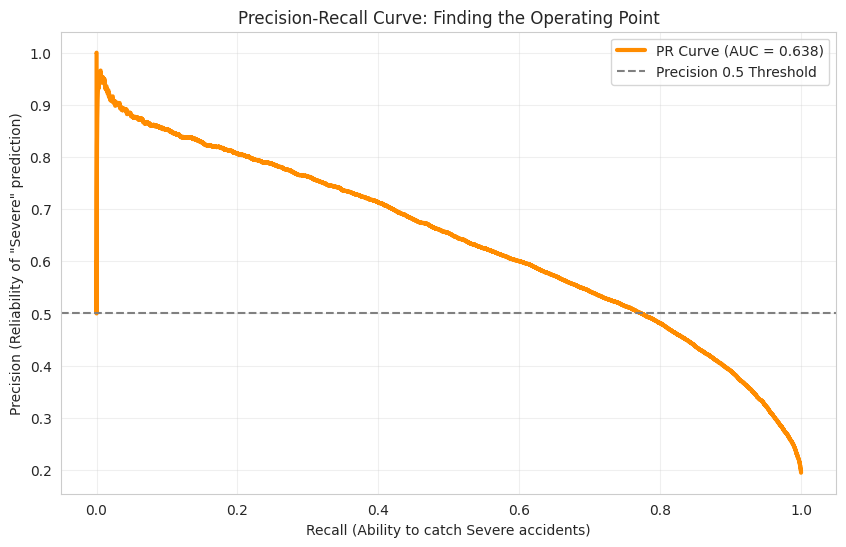

🎯 Optimization Results:
  To reach 85% Recall, use Threshold: 0.414
  Resulting Precision at this point: 0.437


In [73]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Get the probabilities for the 'Severe' class (Class 1)
# rf_model.predict_proba returns [prob_0, prob_1]
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. Calculate Precision and Recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})', color='darkorange', lw=3)
plt.axhline(y=0.5, color='gray', linestyle='--', label='Precision 0.5 Threshold')

# Annotate current performance (approximate 0.5 threshold)
plt.xlabel('Recall (Ability to catch Severe accidents)')
plt.ylabel('Precision (Reliability of "Severe" prediction)')
plt.title('Precision-Recall Curve: Finding the Operating Point')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Find a custom threshold to hit a specific target (e.g., 85% Recall)
target_recall = 0.85
idx = np.where(recall >= target_recall)[0][-1]
custom_threshold = thresholds[idx]

print(f"🎯 Optimization Results:")
print(f"  To reach {target_recall:.0%} Recall, use Threshold: {custom_threshold:.3f}")
print(f"  Resulting Precision at this point: {precision[idx]:.3f}")

### XGBoost

In [74]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Calculate the weight for the 'Severe' class to handle imbalance
# Formula: count(negative) / count(positive)
weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. Initialize and Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=weight, # This is the magic for imbalanced data
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

print("🚀 Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Evaluate
xgb_pred = xgb_model.predict(X_test)
print("\n📊 XGBOOST CLASSIFICATION REPORT")
print(classification_report(y_test, xgb_pred))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.2 MB/s eta 0:00:00
🚀 Training XGBoost...

📊 XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     80539
           1       0.48      0.81      0.60     19461

    accuracy                           0.79    100000
   macro avg       0.71      0.80      0.73    100000
weighted avg       0.85      0.79      0.81    100000



# Best model

In [75]:
import joblib

# Choose your best model here (e.g., xgb_model or rf_model)
best_model = xgb_model

# Save the model
joblib.dump(best_model, 'accident_severity_model.pkl')

# Save the scaler (Crucial: you need this to process new data later!)
joblib.dump(scaler, 'data_scaler.pkl')

# Save the feature list (so you remember the order of columns)
joblib.dump(final_features, 'feature_columns.pkl')

print("💾 Model, Scaler, and Feature List saved successfully!")

💾 Model, Scaler, and Feature List saved successfully!


In [87]:
import os
print(f"Your files are located at: {os.getcwd()}")

Your files are located at: /content


#Web App

In [77]:
import joblib

# Create a dictionary where Key = State and Value = List of unique Cities in that state
state_city_map = (
    df_enhanced.group_by("State")
    .agg(pl.col("City").unique().sort())
    .to_pandas()
    .set_index("State")["City"]
    .to_dict()
)

joblib.dump(state_city_map, 'state_city_map.pkl')
print("✅ State-City relationship map saved!")

✅ State-City relationship map saved!


In [88]:
import joblib

# Build target_mappings dictionary from df_enhanced
target_mappings = {
    'City': dict(
        df_enhanced.group_by("City")
        .agg(pl.col("Severity").mean().alias("avg"))
        .to_pandas()
        .set_index("City")["avg"]
    ),
    'State': dict(
        df_enhanced.group_by("State")
        .agg(pl.col("Severity").mean().alias("avg"))
        .to_pandas()
        .set_index("State")["avg"]
    ),
    'Weather_Condition': dict(
        df_enhanced.group_by("Weather_Condition")
        .agg(pl.col("Severity").mean().alias("avg"))
        .to_pandas()
        .set_index("Weather_Condition")["avg"]
    ),
    'Wind_Direction': dict(
        df_enhanced.group_by("Wind_Direction")
        .agg(pl.col("Severity").mean().alias("avg"))
        .to_pandas()
        .set_index("Wind_Direction")["avg"]
    ),
}

joblib.dump(target_mappings, 'target_mappings.pkl')
print("✅ target_mappings.pkl saved!")

✅ target_mappings.pkl saved!


In [89]:
!pip install --ignore-installed blinker
!pip install streamlit -q
!pip install pyngrok -q

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)


In [90]:
from pyngrok import ngrok

# Terminate any existing tunnels
ngrok.kill()

# Set your auth token
NGROK_AUTH_TOKEN = "3B7tOOD8rZxci4kg29XQ1wo746d_2zz9m2F51wYd2TgqBi5u8"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

In [93]:
import os
import glob

# Find all pkl files
pkl_files = glob.glob('/content/**/*.pkl', recursive=True)
print("Found .pkl files:")
for f in pkl_files:
    print(f"  {f}")

print(f"\nCurrent working directory: {os.getcwd()}")
print(f"\nFiles in /content:")
for f in os.listdir('/content'):
    print(f"  {f}")

Found .pkl files:
  /content/accident_severity_model.pkl
  /content/state_city_map.pkl
  /content/feature_columns.pkl
  /content/data_scaler.pkl
  /content/target_mappings.pkl

Current working directory: /content

Files in /content:
  .config
  app.py
  accident_severity_model.pkl
  state_city_map.pkl
  feature_columns.pkl
  data
  .ipynb_checkpoints
  data_scaler.pkl
  target_mappings.pkl
  sample_data


In [94]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import os

# --- 1. SETTINGS & ASSET LOADING ---
st.set_page_config(page_title="Accident Severity AI", layout="wide")

BASE_DIR = "/content"

@st.cache_resource
def load_assets():
    model          = joblib.load(os.path.join(BASE_DIR, 'accident_severity_model.pkl'))
    scaler         = joblib.load(os.path.join(BASE_DIR, 'data_scaler.pkl'))
    features       = joblib.load(os.path.join(BASE_DIR, 'feature_columns.pkl'))
    mappings       = joblib.load(os.path.join(BASE_DIR, 'target_mappings.pkl'))
    state_city_map = joblib.load(os.path.join(BASE_DIR, 'state_city_map.pkl'))
    return model, scaler, features, mappings, state_city_map

model, scaler, features, mappings, state_city_map = load_assets()

# --- 2. APP UI ---
st.title("🛡️ US Accident Severity Predictor")
st.markdown("Fill in the details below to analyze the risk level of an accident.")

with st.form("prediction_form"):

    # ROW 1: Location
    st.subheader("📍 Location Details")
    col1, col2 = st.columns(2)
    with col1:
        all_states = sorted(list(state_city_map.keys()))
        state = st.selectbox("State", options=all_states)
    with col2:
        available_cities = sorted(list(state_city_map.get(state, ["Unknown"])))
        city = st.selectbox("City", options=available_cities)

    st.divider()

    # ROW 2: Weather
    st.subheader("🌤️ Weather & Atmospheric Conditions")
    w_col1, w_col2, w_col3 = st.columns(3)
    with w_col1:
        weather = st.selectbox("Weather Condition", options=sorted(list(mappings['Weather_Condition'].keys())))
        temp    = st.slider("Temperature (°F)", -20, 120, 70)
    with w_col2:
        humidity = st.slider("Humidity (%)", 0, 100, 50)
        pressure = st.number_input("Pressure (in)", value=29.9, step=0.1)
    with w_col3:
        wind_speed = st.number_input("Wind Speed (mph)", value=5.0, step=1.0)
        wind_dir   = st.selectbox("Wind Direction", options=sorted(list(mappings['Wind_Direction'].keys())))

    st.divider()

    # ROW 3: Time & Road
    st.subheader("🛣️ Time & Road Factors")
    r_col1, r_col2, r_col3 = st.columns(3)
    with r_col1:
        hour  = st.slider("Hour (0-23)", 0, 23, 12)
        month = st.slider("Month (1-12)", 1, 12, 6)
    with r_col2:
        dist       = st.number_input("Distance Impacted (mi)", value=0.5, step=0.1, min_value=0.0)
        is_weekend = st.toggle("Is Weekend?")
    with r_col3:
        road_opts      = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                          'No_Exit', 'Railway', 'Station', 'Stop', 'Traffic_Signal']
        selected_roads = st.multiselect("Road Features Nearby", options=road_opts)

    predict_btn = st.form_submit_button("⚡ Analyze Severity", use_container_width=True, type="primary")

# --- 3. PREDICTION LOGIC ---
if predict_btn:
    # Build input dictionary
    input_dict = {f: 0 for f in features}

    # Target encoded averages
    input_dict['City_Sev_Avg']              = mappings['City'].get(city, 2.2)
    input_dict['State_Sev_Avg']             = mappings['State'].get(state, 2.2)
    input_dict['Weather_Condition_Sev_Avg'] = mappings['Weather_Condition'].get(weather, 2.2)
    input_dict['Wind_Direction_Sev_Avg']    = mappings['Wind_Direction'].get(wind_dir, 2.2)

    # Numeric & temporal
    input_dict['Temperature(F)']  = temp
    input_dict['Humidity(%)']     = humidity
    input_dict['Pressure(in)']    = pressure
    input_dict['Wind_Speed(mph)'] = wind_speed
    input_dict['Distance(mi)']    = dist
    input_dict['Hour']            = hour
    input_dict['Month']           = month
    input_dict['Is_Weekend']      = 1 if is_weekend else 0
    input_dict['Is_Night']        = 1 if (hour < 6 or hour > 20) else 0

    # Derived features
    input_dict['Log_Distance']        = np.log(dist + 0.1)
    input_dict['Road_Feature_Count']  = len(selected_roads)
    input_dict['Night_Low_Vis']       = 1 if (hour < 6 or hour > 20) else 0
    input_dict['High_Speed_Potential']= 1 if dist > 1 else 0
    input_dict['Impact_Intensity']    = dist / (1 + 1)  # duration unknown, use 1 min default

    # Road features
    for road in selected_roads:
        if road in input_dict:
            input_dict[road] = 1

    # Scale and predict
    input_df     = pd.DataFrame([input_dict])[features]
    input_scaled = scaler.transform(input_df)
    prob         = model.predict_proba(input_scaled)[0][1]

    # Results
    st.divider()
    st.subheader("🔍 Prediction Result")

    col_res1, col_res2 = st.columns(2)
    with col_res1:
        if prob > 0.5:
            st.error(f"⚠️ HIGH SEVERITY RISK")
            st.metric("Probability of Severe Accident", f"{prob:.1%}")
            st.write("This accident is likely to result in **significant road closure (Level 3 or 4)**.")
        else:
            st.success(f"✅ LOW SEVERITY RISK")
            st.metric("Probability of Low Severity", f"{1 - prob:.1%}")
            st.write("This is likely a **minor incident with low traffic impact (Level 1 or 2)**.")

    with col_res2:
        st.progress(float(prob))
        st.caption(f"Severe risk score: {prob:.3f} | Threshold: 0.500")

Writing app.py


In [95]:
import os
from pyngrok import ngrok

ngrok.kill()
os.system("pkill -f streamlit")

import time
time.sleep(2)

os.system("streamlit run app.py &")
time.sleep(3)

public_url = ngrok.connect(8501).public_url
print(f"🔗 YOUR WEB APP LINK: {public_url}")

🔗 YOUR WEB APP LINK: https://f036-34-82-3-195.ngrok-free.app


In [92]:
# Start Streamlit in the background
import os
os.system("streamlit run app.py &")

# Open the tunnel
public_url = ngrok.connect(8501).public_url
print(f"🔗 YOUR WEB APP LINK: {public_url}")

🔗 YOUR WEB APP LINK: https://0fb1-34-82-3-195.ngrok-free.app
